<a href="https://colab.research.google.com/github/Anaaaslagi/Tugas1A_AnasGhifari_5026221155/blob/main/Week2_APPSREV_TJ_Transjakarta_Preprocessing_(Anas).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Instalasi Library

In [ ]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

## Upload Dataset File

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Assuming the uploaded file is a CSV
  try:
    df_tj = pd.read_csv(io.BytesIO(uploaded[fn]))
    print("Successfully loaded CSV into df_tj")
  except pd.errors.ParserError:
      print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
      df_tj = pd.DataFrame() # Create an empty DataFrame if parsing fails
  except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df_tj = pd.DataFrame()


Saving df_tj to df_tj
User uploaded file "df_tj" with length 856257 bytes
Successfully loaded CSV into df_tj


In [ ]:
df_tj

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,01a956bc-8356-4eec-8bd6-85644d311be0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Udah hampir sempurna ini, mungkin bisa ditingk...",5,0,2.7.1,2025-09-06 12:30:06,NaN,NaN,2.7.1
1,234b7bb0-8ce0-498a-9644-088811e7a521,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kesalahan yang sering terjadi, versi yang lebi...",4,0,2.7.1,2025-09-06 11:03:16,NaN,NaN,2.7.1
2,06a6c78b-8a8d-4395-9ab7-7ecdd405e7f9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.7.1,2025-09-06 04:19:05,NaN,NaN,2.7.1
3,9ec5f40b-63e5-46d3-a9cf-85f8aa8bda29,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong Gate scan nya Di perbaiki dan di bikin ...,5,0,2.7.1,2025-09-06 01:45:32,NaN,NaN,2.7.1
4,3f1c44b5-aef1-4228-aaa2-d647488808c4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi tidak bisa memasukan kode otp selalu ...,3,0,NaN,2025-09-05 17:19:45,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2741,cdd9f5f2-b4cb-44c2-814e-860e0688f3d5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantaps,5,5,1.4,2024-05-16 11:10:02,NaN,NaN,1.4
2742,66859930-33cc-484a-9c0a-f25534958578,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah enggak crash kalau pilih profil,5,7,1.8,2024-05-16 04:52:59,NaN,NaN,1.8
2743,eb386bcd-d074-448e-b636-8f8b4d20ecb1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",1,7,1.4,2024-05-12 09:42:40,NaN,NaN,1.4
2744,43b40878-dcff-44b8-bed5-2dfb89bc0880,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi gak jelas, server eror, loading lama,...",1,23,1.4,2024-05-11 13:43:39,"Halo Teguh Aliansyah,\nTerima kasih untuk masu...",2024-05-23 06:29:46,1.4


In [ ]:
df_tj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2746 entries, 0 to 2745
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              2746 non-null   object
 1   userName              2746 non-null   object
 2   userImage             2746 non-null   object
 3   content               2746 non-null   object
 4   score                 2746 non-null   int64 
 5   thumbsUpCount         2746 non-null   int64 
 6   reviewCreatedVersion  2324 non-null   object
 7   at                    2746 non-null   object
 8   replyContent          4 non-null      object
 9   repliedAt             4 non-null      object
 10  appVersion            2324 non-null   object
dtypes: int64(2), object(9)
memory usage: 236.1+ KB


In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download Indonesian stopwords if not available
nltk.download('stopwords')
indonesian_stopwords = set(stopwords.words('indonesian'))

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_tj[text_column].dropna().astype(str))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_tj.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"Udah hampir sempurna ini, mungkin bisa ditingk...",5,0,2.7.1,2025-09-06 12:30:06,NaN,NaN
1,"kesalahan yang sering terjadi, versi yang lebi...",4,0,2.7.1,2025-09-06 11:03:16,NaN,NaN
2,ok,5,0,2.7.1,2025-09-06 04:19:05,NaN,NaN
3,Tolong Gate scan nya Di perbaiki dan di bikin ...,5,0,2.7.1,2025-09-06 01:45:32,NaN,NaN
4,aplikasi tidak bisa memasukan kode otp selalu ...,3,0,NaN,2025-09-05 17:19:45,NaN,NaN
...,...,...,...,...,...,...,...
2741,Mantaps,5,5,1.4,2024-05-16 11:10:02,NaN,NaN
2742,Sudah enggak crash kalau pilih profil,5,7,1.8,2024-05-16 04:52:59,NaN,NaN
2743,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",1,7,1.4,2024-05-12 09:42:40,NaN,NaN
2744,"Aplikasi gak jelas, server eror, loading lama,...",1,23,1.4,2024-05-11 13:43:39,"Halo Teguh Aliansyah,\nTerima kasih untuk masu...",2024-05-23 06:29:46


## Tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Download punkt if not already present
nltk.download('punkt')
nltk.download('punkt_tab') # Download the punkt_tab resource

def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens

# Apply tokenization to the 'content' column
df_tj['tokenized_content'] = df_tj['content'].astype(str).apply(tokenize_text)

# Display the DataFrame with the new 'tokenized_content' column
df_tj[['content', 'tokenized_content']]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,content,tokenized_content
0,"Udah hampir sempurna ini, mungkin bisa ditingk...","[Udah, hampir, sempurna, ini, ,, mungkin, bisa..."
1,"kesalahan yang sering terjadi, versi yang lebi...","[kesalahan, yang, sering, terjadi, ,, versi, y..."
2,ok,[ok]
3,Tolong Gate scan nya Di perbaiki dan di bikin ...,"[Tolong, Gate, scan, nya, Di, perbaiki, dan, d..."
4,aplikasi tidak bisa memasukan kode otp selalu ...,"[aplikasi, tidak, bisa, memasukan, kode, otp, ..."
...,...,...
2741,Mantaps,[Mantaps]
2742,Sudah enggak crash kalau pilih profil,"[Sudah, enggak, crash, kalau, pilih, profil]"
2743,"Aplikasi kocag, gk becus bikin aplikasi, masuk...","[Aplikasi, kocag, ,, gk, becus, bikin, aplikas..."
2744,"Aplikasi gak jelas, server eror, loading lama,...","[Aplikasi, gak, jelas, ,, server, eror, ,, loa..."


In [ ]:
# Example Tokenization

example_token = df_tj['content'].iloc[2744]

print('Example content to tokenize:')
print(example_token)

print('\nTokenized content:')
print(word_tokenize(example_token))

Example content to tokenize:
Aplikasi gak jelas, server eror, loading lama, pencarian rute susah, posisi bus kacau, UI gak menarik, gak jadi niat mau naik tj kalau kaya gini.

Tokenized content:
['Aplikasi', 'gak', 'jelas', ',', 'server', 'eror', ',', 'loading', 'lama', ',', 'pencarian', 'rute', 'susah', ',', 'posisi', 'bus', 'kacau', ',', 'UI', 'gak', 'menarik', ',', 'gak', 'jadi', 'niat', 'mau', 'naik', 'tj', 'kalau', 'kaya', 'gini', '.']


## Lowering Case

In [ ]:
def lower_tokenized(tokens):
    return [token.lower() for token in tokens]

df_tj['lower_tokenized_content'] = df_tj['tokenized_content'].apply(lower_tokenized)
df_tj[['tokenized_content', 'lower_tokenized_content']]

,tokenized_content,lower_tokenized_content
0,"[Udah, hampir, sempurna, ini, ,, mungkin, bisa...","[udah, hampir, sempurna, ini, ,, mungkin, bisa..."
1,"[kesalahan, yang, sering, terjadi, ,, versi, y...","[kesalahan, yang, sering, terjadi, ,, versi, y..."
2,[ok],[ok]
3,"[Tolong, Gate, scan, nya, Di, perbaiki, dan, d...","[tolong, gate, scan, nya, di, perbaiki, dan, d..."
4,"[aplikasi, tidak, bisa, memasukan, kode, otp, ...","[aplikasi, tidak, bisa, memasukan, kode, otp, ..."
...,...,...
2741,[Mantaps],[mantaps]
2742,"[Sudah, enggak, crash, kalau, pilih, profil]","[sudah, enggak, crash, kalau, pilih, profil]"
2743,"[Aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, gk, becus, bikin, aplikas..."
2744,"[Aplikasi, gak, jelas, ,, server, eror, ,, loa...","[aplikasi, gak, jelas, ,, server, eror, ,, loa..."


In [ ]:
# Lowering Case
example_lowering = df_tj['tokenized_content'].iloc[3]

print('Example token to lower:')
print(example_lowering)

lowered_tokens = [token.lower() for token in example_lowering]

print('\nLower Tokenized content:')
print(lowered_tokens)

Example token to lower:
['Tolong', 'Gate', 'scan', 'nya', 'Di', 'perbaiki', 'dan', 'di', 'bikin', 'mudah', ',', 'soalnya', 'kadang', 'kadang', 'ngga', 'bisa', 'tap', 'in', 'atau', 'tap', 'out', 'di', 'halte', '.', 'kan', 'percuma', 'ada', 'fitur', 'pembayaran', 'digital', 'jika', 'alatnya', 'ngga', 'bisa', 'di', 'gunakan', '.']

Lower Tokenized content:
['tolong', 'gate', 'scan', 'nya', 'di', 'perbaiki', 'dan', 'di', 'bikin', 'mudah', ',', 'soalnya', 'kadang', 'kadang', 'ngga', 'bisa', 'tap', 'in', 'atau', 'tap', 'out', 'di', 'halte', '.', 'kan', 'percuma', 'ada', 'fitur', 'pembayaran', 'digital', 'jika', 'alatnya', 'ngga', 'bisa', 'di', 'gunakan', '.']


##Stopwords Removal
Indonesian Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
print(len(indonesian_stopwords))

758


,Word,Frequency
0,aplikasi,1055
1,membantu,617
2,bus,546
3,transjakarta,541
4,nya,491
5,rute,465
6,mudah,374
7,banget,338
8,bagus,306
9,memudahkan,271


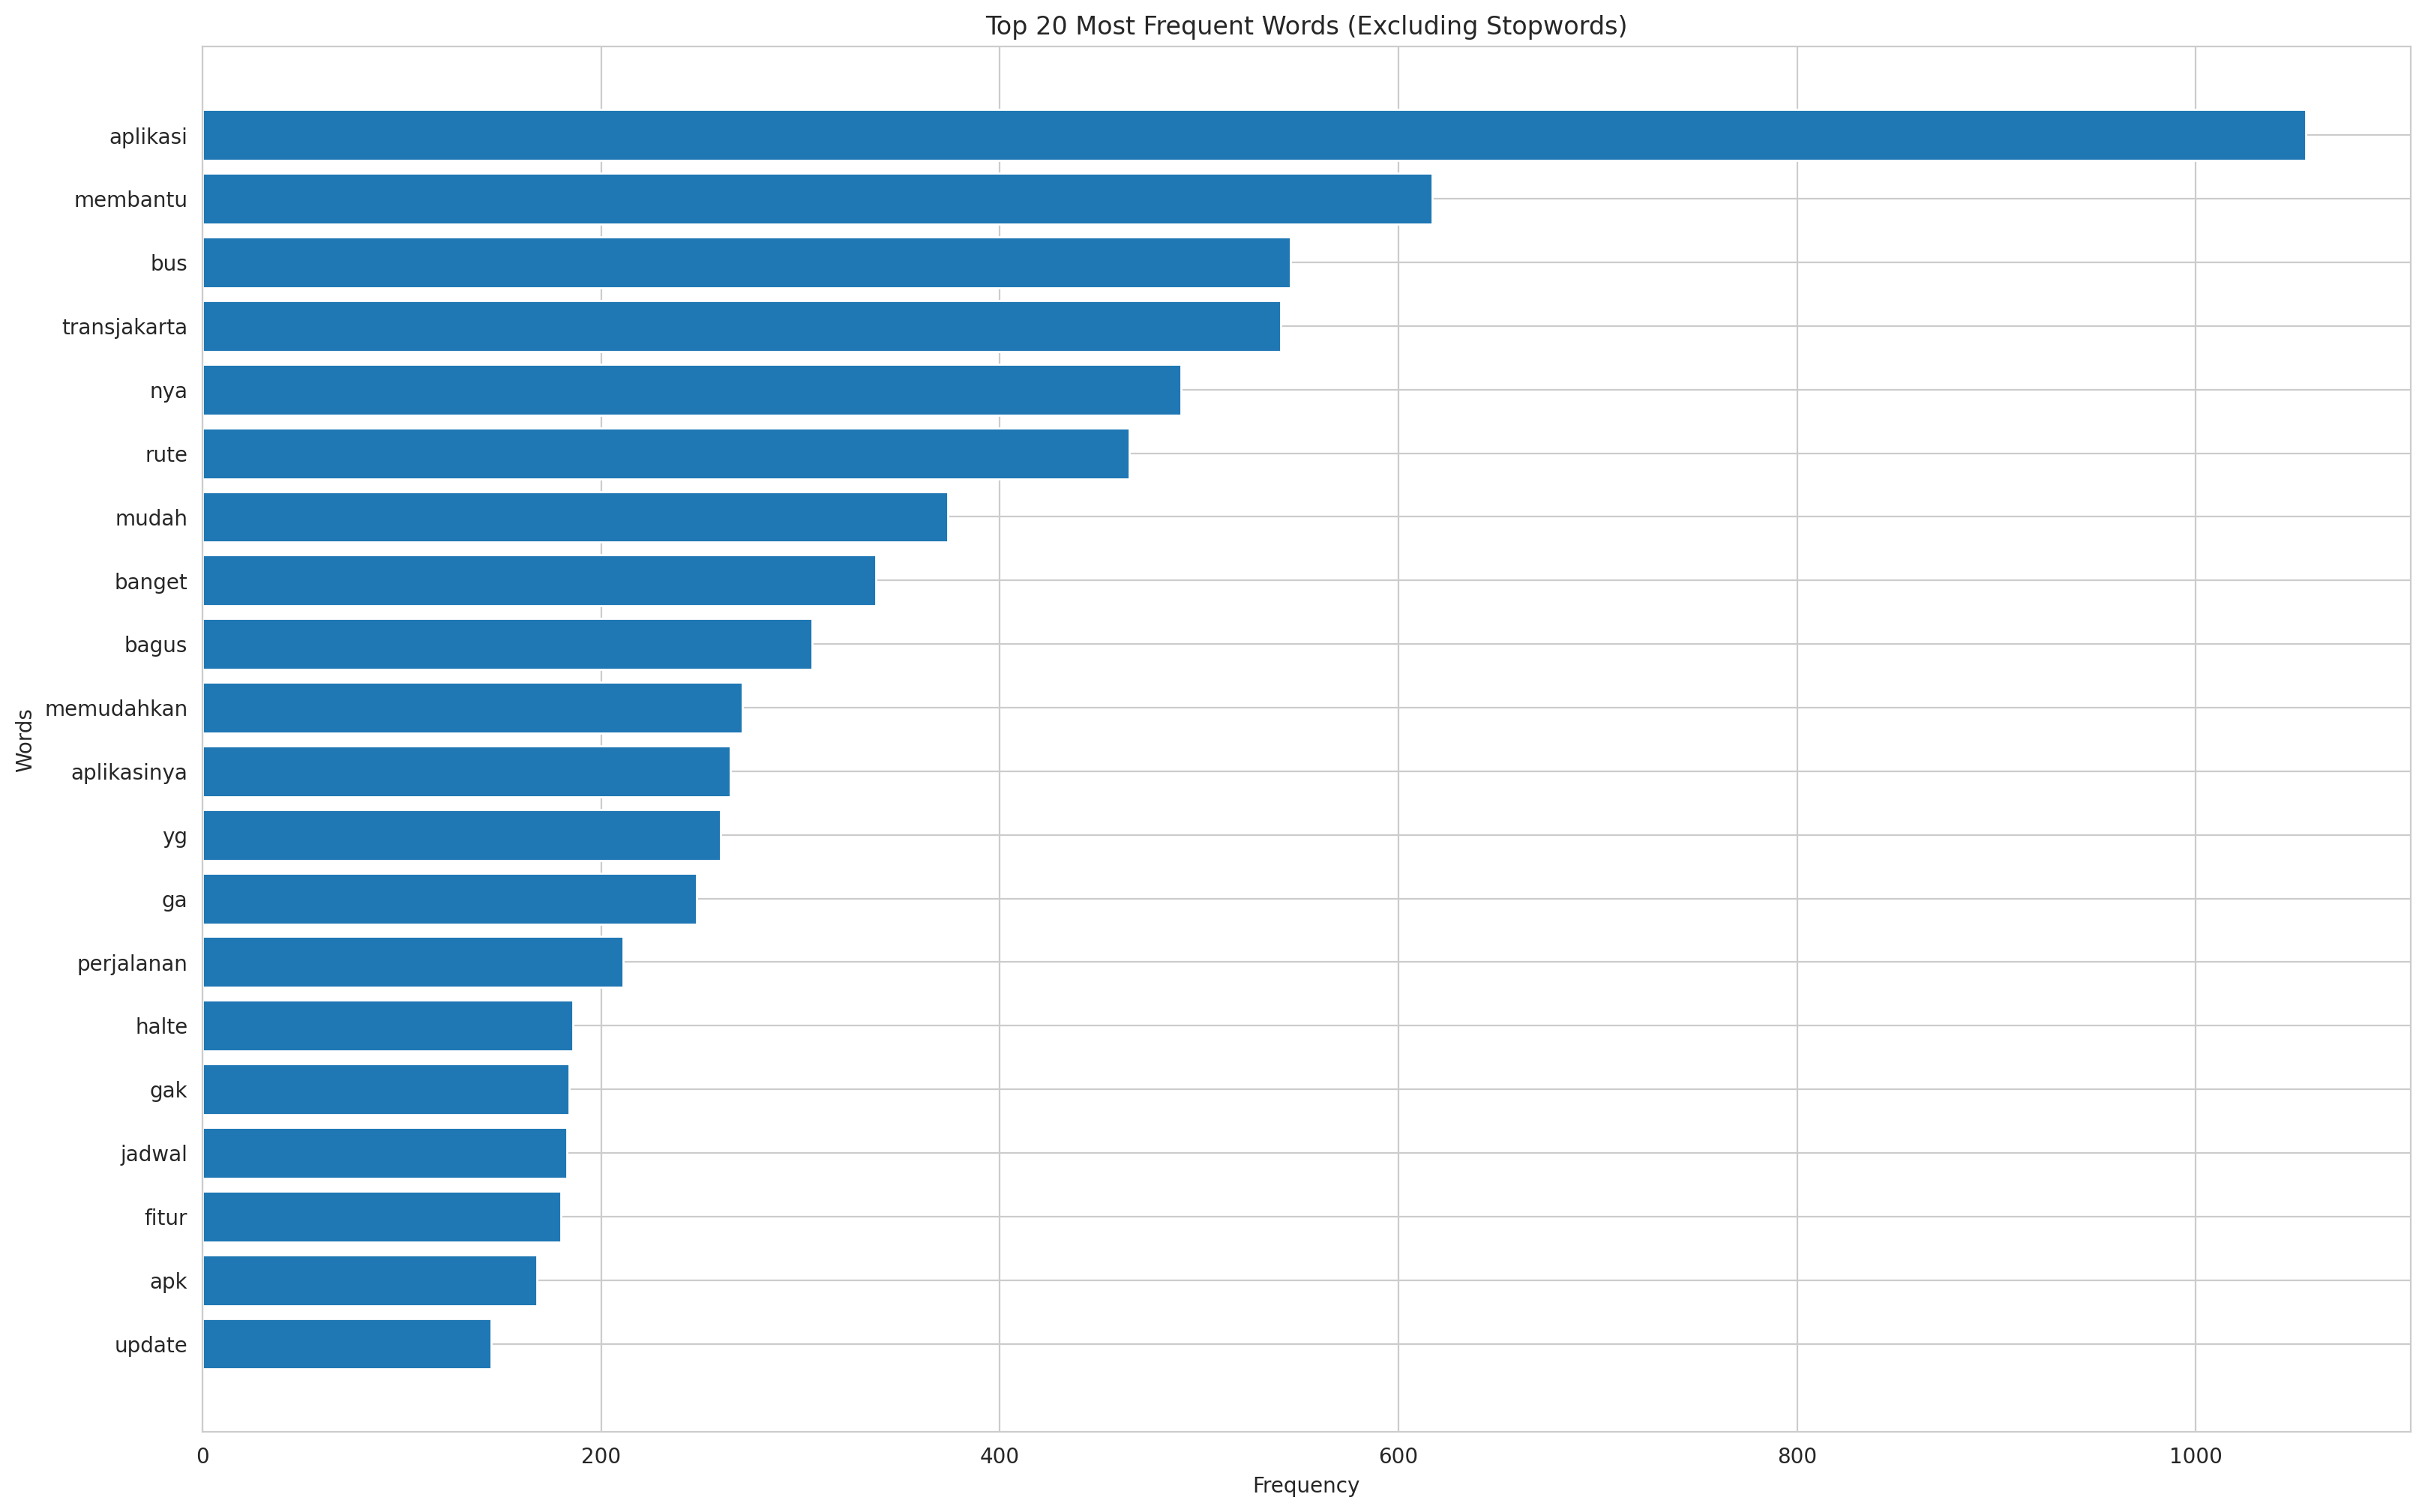

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_tj[text_column].dropna().astype(str))

# Tokenize words and remove stopwords
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in indonesian_stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(20)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words
plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (Excluding Stopwords)")
plt.show()

In [ ]:
common_words

[('aplikasi', 1055),
 ('membantu', 617),
 ('bus', 546),
 ('transjakarta', 541),
 ('nya', 491),
 ('rute', 465),
 ('mudah', 374),
 ('banget', 338),
 ('bagus', 306),
 ('memudahkan', 271),
 ('aplikasinya', 265),
 ('yg', 260),
 ('ga', 248),
 ('perjalanan', 211),
 ('halte', 186),
 ('gak', 184),
 ('jadwal', 183),
 ('fitur', 180),
 ('apk', 168),
 ('update', 145)]

Custom Stopwords

In [ ]:
# Tambah custom stopwords
custom_stopwords = ["good", "nya", "banget", "yg", "ga", "gak", "apk", "update", "gk", "mna", "kmna", "jdi"]

# Pastikan indonesian_stopwords juga merupakan sebuah list atau set
# Asumsi indonesian_stopwords sudah ada dan berbentuk list
# indonesian_stopwords = [...]

# 2. Gabungkan stopwords bawaan dan custom stopwords
# --- PERBAIKAN DI SINI ---
# Ubah list menjadi set agar bisa menggunakan metode .union()
all_stopwords = set(indonesian_stopwords).union(custom_stopwords)

# --- Alternatif lain yang lebih singkat ---
# all_stopwords = set(indonesian_stopwords + custom_stopwords)


def remove_stopwords(tokens):
    return [token for token in tokens if token not in all_stopwords]

df_tj['removed_stopwords_content'] = df_tj['lower_tokenized_content'].apply(remove_stopwords)
df_tj[['lower_tokenized_content', 'removed_stopwords_content']]

print("Updated stopwords:", all_stopwords)

Updated stopwords: {'kira', 'berujar', 'digunakan', 'berupa', 'keseluruhan', 'toh', 'memisalkan', 'yakni', 'dialah', 'biasanya', 'sinilah', 'cara', 'jikalau', 'siap', 'ibu', 'diucapkannya', 'terbanyak', 'tunjuk', 'bagai', 'menyiapkan', 'sebaliknya', 'tuturnya', 'selama-lamanya', 'diibaratkannya', 'mana', 'kapankah', 'menandaskan', 'segalanya', 'sejumlah', 'sering', 'diperlukannya', 'dimulai', 'ingat-ingat', 'padahal', 'dimungkinkan', 'empat', 'usah', 'bersiap-siap', 'umumnya', 'terhadap', 'tersebut', 'jangan', 'olehnya', 'sini', 'dikatakannya', 'diakhiri', 'kebetulan', 'lima', 'gunakan', 'kenapa', 'menantikan', 'meminta', 'akankah', 'begitupun', 'merasa', 'sementara', 'kecil', 'hanyalah', 'semisal', 'bersama-sama', 'terlebih', 'yg', 'besar', 'perlukah', 'sepantasnyalah', 'kedua', 'hingga', 'inikah', 'pihaknya', 'berawal', 'betul', 'mampukah', 'sekadarnya', 'artinya', 'inginkah', 'beginikah', 'memperbuat', 'sesudah', 'jawabnya', 'sebut', 'tiga', 'kita', 'untuk', 'memerlukan', 'disini', 

In [ ]:
print(df_tj['lower_tokenized_content'][500])
print(df_tj['removed_stopwords_content'][500])

['terimaksih', 'yg', 'sudah', 'menciptakan', 'aplikasi', 'ini', ',', 'kmna', 'mna', 'jdi', 'lebih', 'gampang', 'buat', 'yg', 'gk', 'ada', 'kendaraan', ',', 'tranformasi', 'nya', 'juga', 'cepet', 'gak', 'lelet', 'fitur', 'fitur', 'di', 'aplikasi', 'ini', 'juga', 'mudah', 'dimengerti', 'dan', 'banyak']
['terimaksih', 'menciptakan', 'aplikasi', ',', 'gampang', 'kendaraan', ',', 'tranformasi', 'cepet', 'lelet', 'fitur', 'fitur', 'aplikasi', 'mudah', 'dimengerti']


## Lemmatization

In [ ]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.9 MB/s eta 0:00:00


In [ ]:
# Import the Sastrawi StemmerFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Create the factory and the stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def lemmatize_text_indonesian(tokens):
    # Sastrawi's stemmer works on a single string, so we stem each token individually
    # This is a simple approach; for efficiency on large datasets, other methods might be better
    lemmatized_tokens = [stemmer.stem(token) for token in tokens]
    return lemmatized_tokens

# Apply the correct Indonesian lemmatization function to your DataFrame
df_tj['lemmatized_content'] = df_tj['removed_stopwords_content'].apply(lemmatize_text_indonesian)



In [ ]:
# Display the result
df_tj[['removed_stopwords_content', 'lemmatized_content']]

,removed_stopwords_content,lemmatized_content
0,"[udah, sempurna, ,, ditingkatkan, ngehubungin,...","[udah, sempurna, , tingkat, ngehubungin, data,..."
1,"[kesalahan, ,, versi, pembaruan, ,, tolong, pe...","[salah, , versi, baru, , tolong, baik]"
2,[ok],[ok]
3,"[tolong, gate, scan, perbaiki, bikin, mudah, ,...","[tolong, gate, scan, baik, bikin, mudah, , kad..."
4,"[aplikasi, memasukan, kode, otp, peringatan, e...","[aplikasi, pasu, kode, otp, ingat, eror]"
...,...,...
2741,[mantaps],[mantaps]
2742,"[crash, pilih, profil]","[crash, pilih, profil]"
2743,"[aplikasi, kocag, ,, becus, bikin, aplikasi, ,...","[aplikasi, kocag, , becus, bikin, aplikasi, , ..."
2744,"[aplikasi, ,, server, eror, ,, loading, ,, pen...","[aplikasi, , server, eror, , loading, , cari, ..."


In [ ]:
print(df_tj['removed_stopwords_content'][10])
print(df_tj['lemmatized_content'][10])

['berulang', 'daftar', 'email', '..', 'kenpa', '...', 'mohon', 'diperbaiki', 'kembali🙏🏻']
['ulang', 'daftar', 'email', '', 'kenpa', '', 'mohon', 'baik', 'kembali']


## Stemming

In [ ]:
import nltk
from nltk.stem import PorterStemmer

nltk.download('punkt')

stemmer = PorterStemmer()

def stem_text(tokens):
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return stemmed_tokens

df_tj['stemmed_content'] = df_tj['lemmatized_content'].apply(stem_text)
df_tj[['lemmatized_content', 'stemmed_content']]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,lemmatized_content,stemmed_content
0,"[udah, sempurna, , tingkat, ngehubungin, data,...","[udah, sempurna, , tingkat, ngehubungin, data,..."
1,"[salah, , versi, baru, , tolong, baik]","[salah, , versi, baru, , tolong, baik]"
2,[ok],[ok]
3,"[tolong, gate, scan, baik, bikin, mudah, , kad...","[tolong, gate, scan, baik, bikin, mudah, , kad..."
4,"[aplikasi, pasu, kode, otp, ingat, eror]","[aplikasi, pasu, kode, otp, ingat, eror]"
...,...,...
2741,[mantaps],[mantap]
2742,"[crash, pilih, profil]","[crash, pilih, profil]"
2743,"[aplikasi, kocag, , becus, bikin, aplikasi, , ...","[aplikasi, kocag, , becu, bikin, aplikasi, , m..."
2744,"[aplikasi, , server, eror, , loading, , cari, ...","[aplikasi, , server, eror, , load, , cari, rut..."


In [ ]:
print(df_tj['lemmatized_content'][2744])
print(df_tj['stemmed_content'][2744])

['aplikasi', '', 'server', 'eror', '', 'loading', '', 'cari', 'rute', 'susah', '', 'posisi', 'bus', 'kacau', '', 'ui', 'tarik', '', 'niat', 'tj', 'kaya', 'gin', '']
['aplikasi', '', 'server', 'eror', '', 'load', '', 'cari', 'rute', 'susah', '', 'posisi', 'bu', 'kacau', '', 'ui', 'tarik', '', 'niat', 'tj', 'kaya', 'gin', '']


## Punctuation Removal

In [ ]:
import string

def remove_punctuation(text):
    if isinstance(text, str):
        translator = str.maketrans('', '', string.punctuation)
        cleaned_text = text.translate(translator)
        return cleaned_text
    else:
        return text

df_tj['stemmed_content'] = df_tj['stemmed_content'].astype(str)
df_tj['cleaned_content'] = df_tj['stemmed_content'].apply(remove_punctuation)
df_tj[['stemmed_content', 'cleaned_content']]

,stemmed_content,cleaned_content
0,"['udah', 'sempurna', '', 'tingkat', 'ngehubung...",udah sempurna tingkat ngehubungin data bu kar...
1,"['salah', '', 'versi', 'baru', '', 'tolong', '...",salah versi baru tolong baik
2,['ok'],ok
3,"['tolong', 'gate', 'scan', 'baik', 'bikin', 'm...",tolong gate scan baik bikin mudah kadang kada...
4,"['aplikasi', 'pasu', 'kode', 'otp', 'ingat', '...",aplikasi pasu kode otp ingat eror
...,...,...
2741,['mantap'],mantap
2742,"['crash', 'pilih', 'profil']",crash pilih profil
2743,"['aplikasi', 'kocag', '', 'becu', 'bikin', 'ap...",aplikasi kocag becu bikin aplikasi masuk ker...
2744,"['aplikasi', '', 'server', 'eror', '', 'load',...",aplikasi server eror load cari rute susah ...


##Common Word

In [ ]:
import nltk
import string
# Mengimpor stopwords Bahasa Indonesia
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# --- Download Resource yang Diperlukan ---
# 'stopwords' untuk daftar kata umum (yang, di, ke, dari)
# 'punkt' untuk tokenisasi (memecah kalimat menjadi kata)
nltk.download('stopwords')
nltk.download('punkt')

# --- 1. Definisikan 'all_stopwords' menggunakan Bahasa Indonesia ---
# Mengambil daftar stopwords Bahasa Indonesia
# Pastikan Anda sudah menjalankan nltk.download('stopwords')
stop_words_indonesian = set(stopwords.words('indonesian'))
punctuation = set(string.punctuation)
all_stopwords = stop_words_indonesian.union(punctuation)

# --- 2. Fungsi yang Disederhanakan untuk Bahasa Indonesia ---
# Bagian Part-of-Speech (POS) tagging dihapus karena modelnya untuk Bahasa Inggris
def remove_stopwords_indonesian(text):
    # Memastikan input adalah string
    if not isinstance(text, str):
        return "" # Mengembalikan string kosong jika input bukan teks

    # Menggunakan word_tokenize untuk hasil yang lebih baik
    tokens = word_tokenize(text.lower()) # Mengubah teks menjadi huruf kecil

    filtered_tokens = []
    for token in tokens:
        # Simpan token jika bukan stopword dan bukan tanda baca
        if token not in all_stopwords:
            filtered_tokens.append(token)

    return " ".join(filtered_tokens)

df_tj['cleaned_content_no_common'] =df_tj['cleaned_content'].apply(remove_stopwords_indonesian)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
df_tj

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,tokenized_content,lower_tokenized_content,removed_stopwords_content,lemmatized_content,stemmed_content,cleaned_content,cleaned_content_no_common
0,01a956bc-8356-4eec-8bd6-85644d311be0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Udah hampir sempurna ini, mungkin bisa ditingk...",5,0,2.7.1,2025-09-06 12:30:06,NaN,NaN,2.7.1,"[Udah, hampir, sempurna, ini, ,, mungkin, bisa...","[udah, hampir, sempurna, ini, ,, mungkin, bisa...","[udah, sempurna, ,, ditingkatkan, ngehubungin,...","[udah, sempurna, , tingkat, ngehubungin, data,...","['udah', 'sempurna', '', 'tingkat', 'ngehubung...",udah sempurna tingkat ngehubungin data bu kar...,udah sempurna tingkat ngehubungin data bu karn...
1,234b7bb0-8ce0-498a-9644-088811e7a521,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kesalahan yang sering terjadi, versi yang lebi...",4,0,2.7.1,2025-09-06 11:03:16,NaN,NaN,2.7.1,"[kesalahan, yang, sering, terjadi, ,, versi, y...","[kesalahan, yang, sering, terjadi, ,, versi, y...","[kesalahan, ,, versi, pembaruan, ,, tolong, pe...","[salah, , versi, baru, , tolong, baik]","['salah', '', 'versi', 'baru', '', 'tolong', '...",salah versi baru tolong baik,salah versi tolong
2,06a6c78b-8a8d-4395-9ab7-7ecdd405e7f9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.7.1,2025-09-06 04:19:05,NaN,NaN,2.7.1,[ok],[ok],[ok],[ok],['ok'],ok,ok
3,9ec5f40b-63e5-46d3-a9cf-85f8aa8bda29,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong Gate scan nya Di perbaiki dan di bikin ...,5,0,2.7.1,2025-09-06 01:45:32,NaN,NaN,2.7.1,"[Tolong, Gate, scan, nya, Di, perbaiki, dan, d...","[tolong, gate, scan, nya, di, perbaiki, dan, d...","[tolong, gate, scan, perbaiki, bikin, mudah, ,...","[tolong, gate, scan, baik, bikin, mudah, , kad...","['tolong', 'gate', 'scan', 'baik', 'bikin', 'm...",tolong gate scan baik bikin mudah kadang kada...,tolong gate scan bikin mudah kadang kadang ngg...
4,3f1c44b5-aef1-4228-aaa2-d647488808c4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi tidak bisa memasukan kode otp selalu ...,3,0,NaN,2025-09-05 17:19:45,NaN,NaN,NaN,"[aplikasi, tidak, bisa, memasukan, kode, otp, ...","[aplikasi, tidak, bisa, memasukan, kode, otp, ...","[aplikasi, memasukan, kode, otp, peringatan, e...","[aplikasi, pasu, kode, otp, ingat, eror]","['aplikasi', 'pasu', 'kode', 'otp', 'ingat', '...",aplikasi pasu kode otp ingat eror,aplikasi pasu kode otp eror
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,cdd9f5f2-b4cb-44c2-814e-860e0688f3d5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantaps,5,5,1.4,2024-05-16 11:10:02,NaN,NaN,1.4,[Mantaps],[mantaps],[mantaps],[mantaps],['mantap'],mantap,mantap
2742,66859930-33cc-484a-9c0a-f25534958578,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah enggak crash kalau pilih profil,5,7,1.8,2024-05-16 04:52:59,NaN,NaN,1.8,"[Sudah, enggak, crash, kalau, pilih, profil]","[sudah, enggak, crash, kalau, pilih, profil]","[crash, pilih, profil]","[crash, pilih, profil]","['crash', 'pilih', 'profil']",crash pilih profil,crash pilih profil
2743,eb386bcd-d074-448e-b636-8f8b4d20ecb1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",1,7,1.4,2024-05-12 09:42:40,NaN,NaN,1.4,"[Aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, becus, bikin, aplikasi, ,...","[aplikasi, kocag, , becus, bikin, aplikasi, , ...","['aplikasi', 'kocag', '', 'becu', 'bikin', 'ap...",aplikasi kocag becu bikin aplikasi masuk ker...,aplikasi kocag becu bikin aplikasi masuk kerja...
2744,43b40878-dcff-44b8-bed5-2dfb89bc0880,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi gak jelas, server eror, loading lama,...",1,23,1.4,2024-05-

In [ ]:
from collections import Counter

# Function to get word counts from a list of strings
def get_word_counts(text_list):
    all_words = ' '.join(text_list).split()
    return Counter(all_words)

# Get word counts for both columns
word_counts_cleaned = get_word_counts(df_tj['cleaned_content'])
word_counts_no_common = get_word_counts(df_tj['cleaned_content_no_common'])

# Find words present in cleaned_content but not in cleaned_content_no_common
words_only_in_cleaned = set(word_counts_cleaned.keys()) - set(word_counts_no_common.keys())

# Find words present in cleaned_content_no_common but not in cleaned_content
words_only_in_no_common = set(word_counts_no_common.keys()) - set(word_counts_cleaned.keys())

print("Words present only in 'cleaned_content':")
print(words_only_in_cleaned)

print("\nWords present only in 'cleaned_content_no_common':")
print(words_only_in_no_common)

# You can also compare the total number of unique words
print(f"\nTotal unique words in 'cleaned_content': {len(word_counts_cleaned)}")
print(f"Total unique words in 'cleaned_content_no_common': {len(word_counts_no_common)}")

Words present only in 'cleaned_content':
{'perlu', 'kira', 'tengah', 'dan', 'jadi', 'siap', 'ibu', 'pak', 'tunjuk', 'bagi', 'beberapa', 'nanti', 'mana', 'baik', 'baru', 'depan', 'dapat', 'hanya', 'maka', 'selain', 'tiba', 'mau', 'datang', 'rata', 'saya', 'sekitar', 'kalau', 'sendiri', 'kini', 'betul', 'pada', 'sampai', 'balik', 'ada', 'tambah', 'tiga', 'kita', 'untuk', 'dengan', 'lanjut', 'bulan', 'tahu', 'kembali', 'masalah', 'walaupun', 'kami', 'lewat', 'wah', 'banyak', 'hari', 'kurang', 'lebih', 'serta', 'bisa', 'dua', 'kala', 'sekali', 'guna', 'dalam', 'keluar', 'naik', 'tentu', 'terus', 'buat', 'dekat', 'sangat', 'waktu', 'tempat', 'rasa', 'aku', 'ke', 'ingat', 'luar', 'benar', 'punya', 'malah', 'sana', 'selalu', 'diri', 'seluruh', 'apa', 'ini', 'demikian', 'di', 'apalagi', 'pasti', 'bawah', 'tanya', 'biasa', 'lagi', 'pun', 'lalu', 'ingin', 'lama', 'ikut', 'tepat', 'mula', 'mampu', 'turut', 'saat'}

Words present only in 'cleaned_content_no_common':
set()

Total unique words in 'c

##Sentiment Analysis

In [ ]:
from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_tj['sentiment_polarity'] = df_tj['stemmed_content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_tj['sentiment_subjective'] = df_tj['stemmed_content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)


In [ ]:
df_tj['sentiment_rating'] = df_tj['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [ ]:
df_tj.loc[:,["cleaned_content_no_common","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,cleaned_content_no_common,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,udah sempurna tingkat ngehubungin data bu karn...,5,0.0,0.0,Positive
1,salah versi tolong,4,0.0,0.0,Positive
2,ok,5,0.5,0.5,Positive
3,tolong gate scan bikin mudah kadang kadang ngg...,5,0.0,0.0,Positive
4,aplikasi pasu kode otp eror,3,0.0,0.0,Neutral
...,...,...,...,...,...
2741,mantap,5,0.0,0.0,Positive
2742,crash pilih profil,5,0.0,0.0,Positive
2743,aplikasi kocag becu bikin aplikasi masuk kerja...,1,-0.4,0.4,Negative
2744,aplikasi server eror load cari rute susah posi...,1,0.0,0.0,Negative


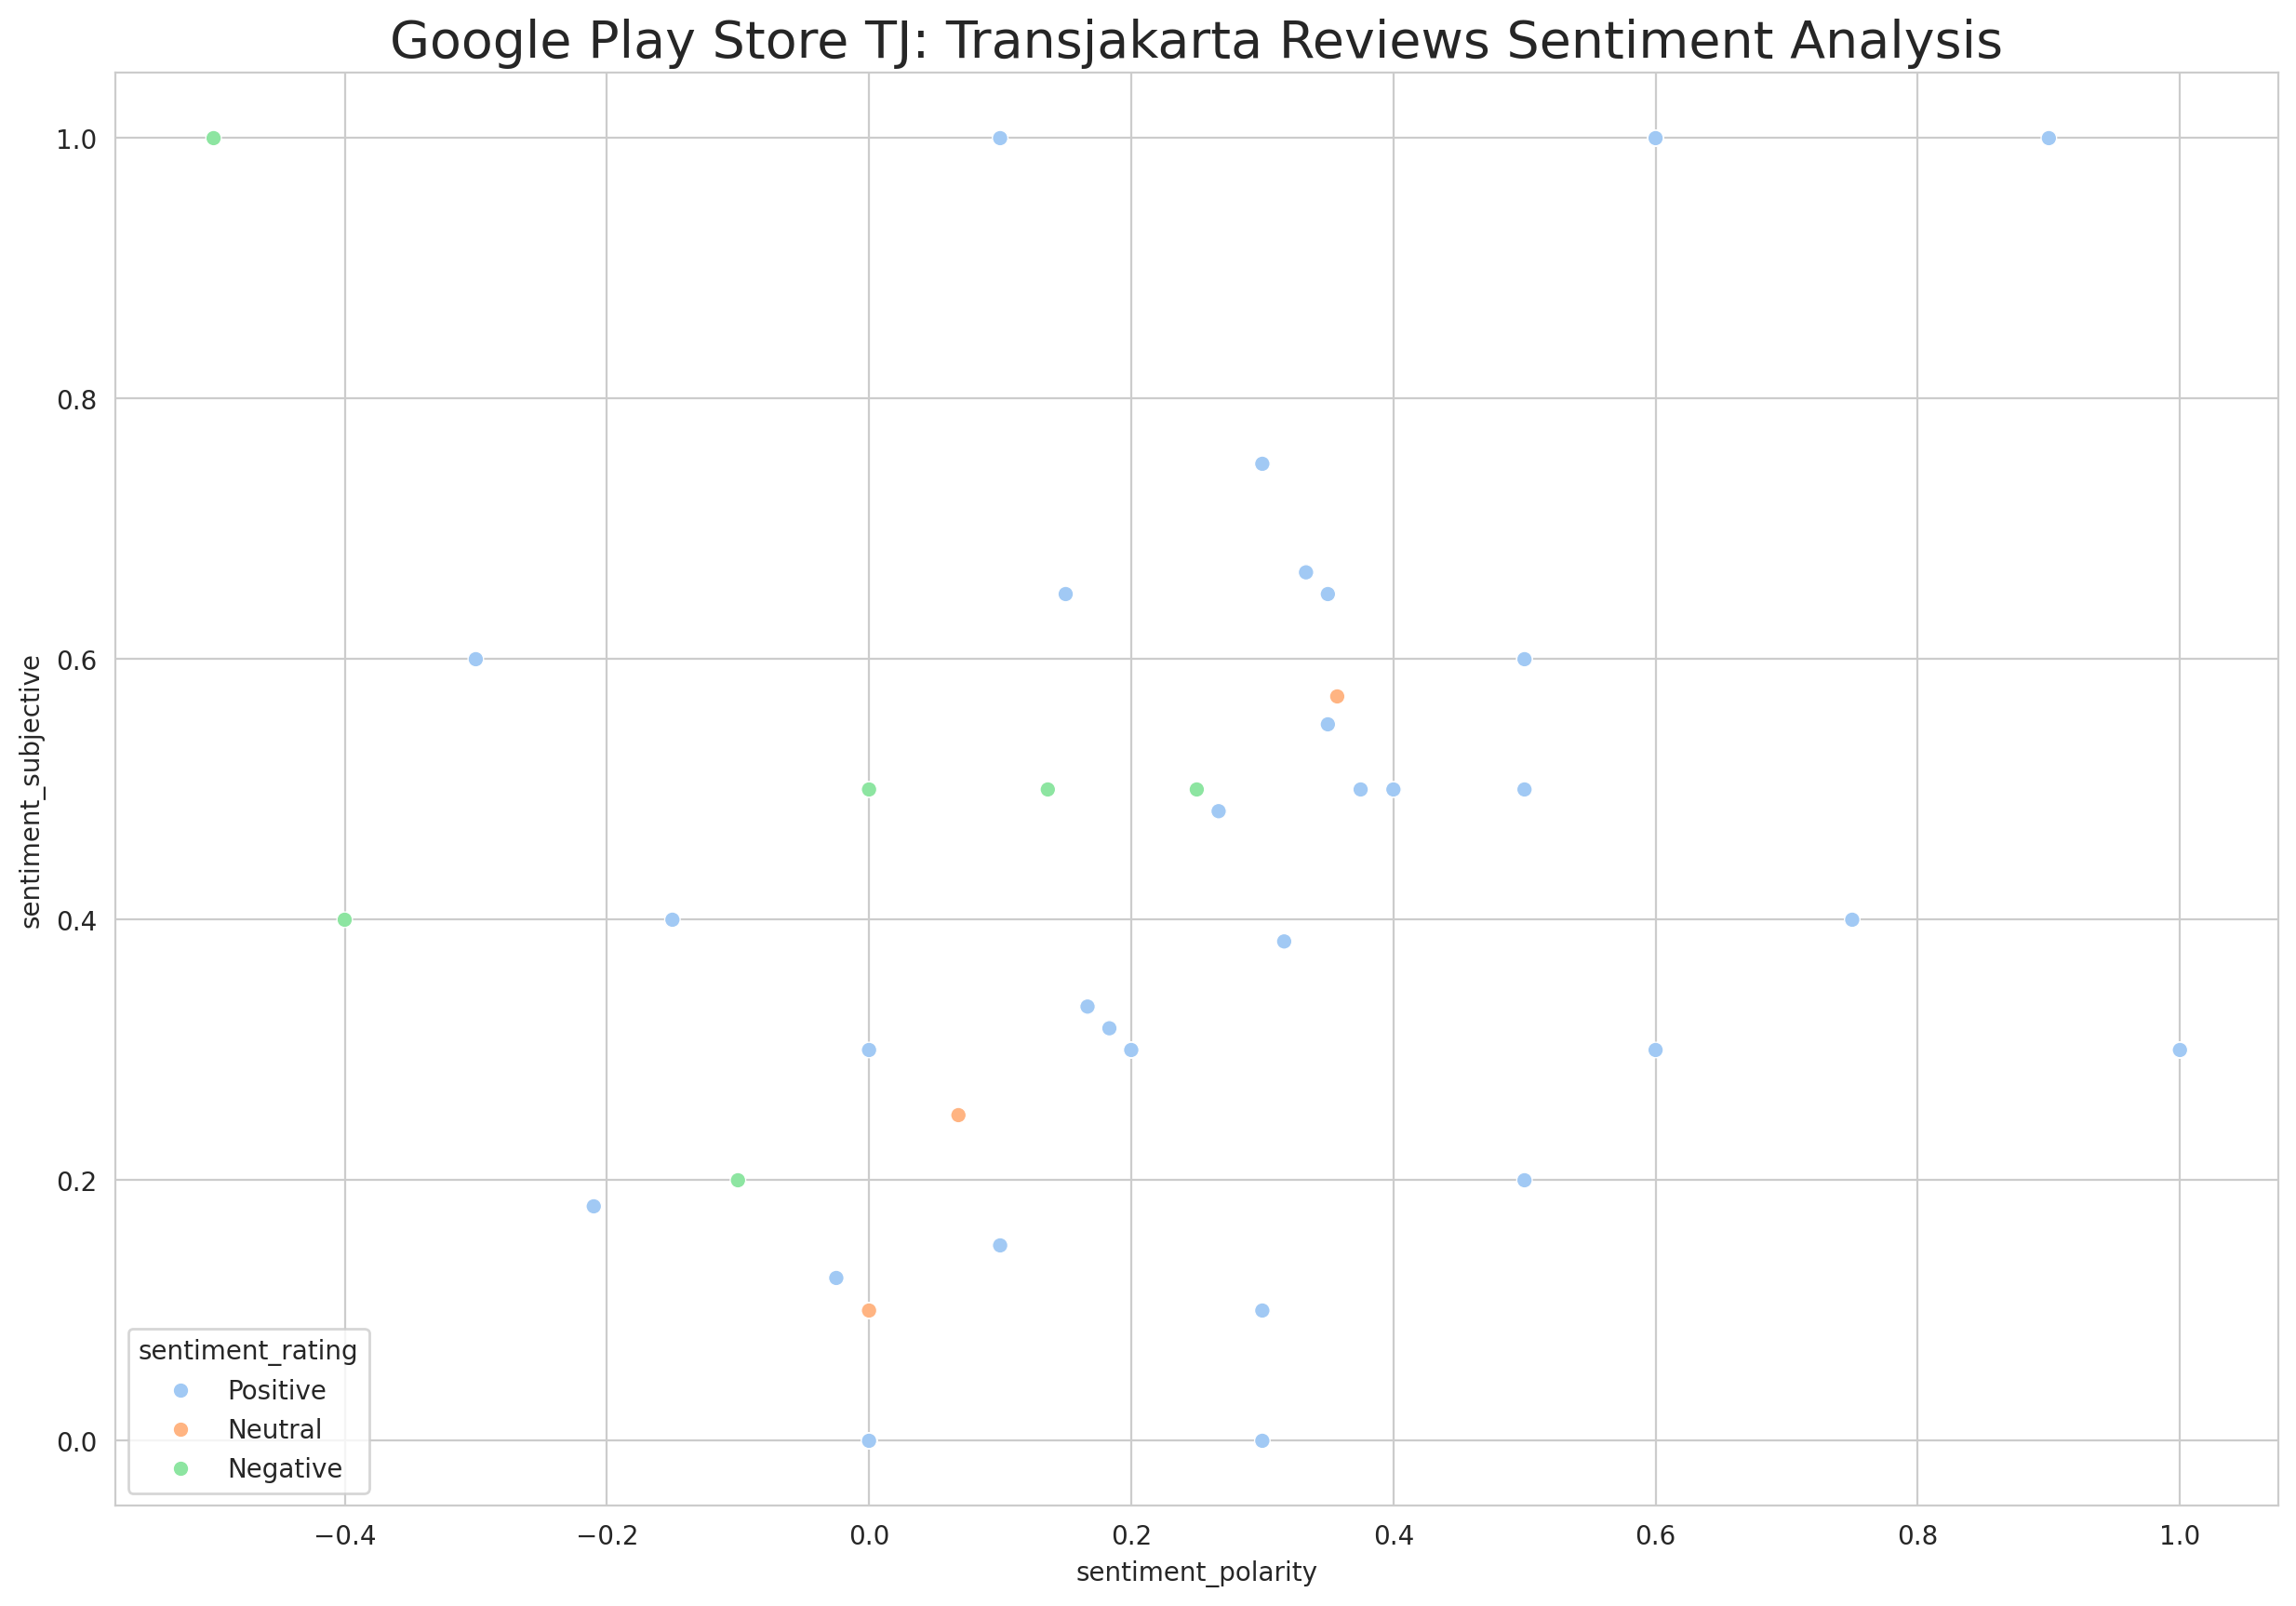

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_tj['sentiment_polarity'], y=df_tj['sentiment_subjective'],
                hue=df_tj['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store TJ: Transjakarta Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [ ]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipython-input-2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


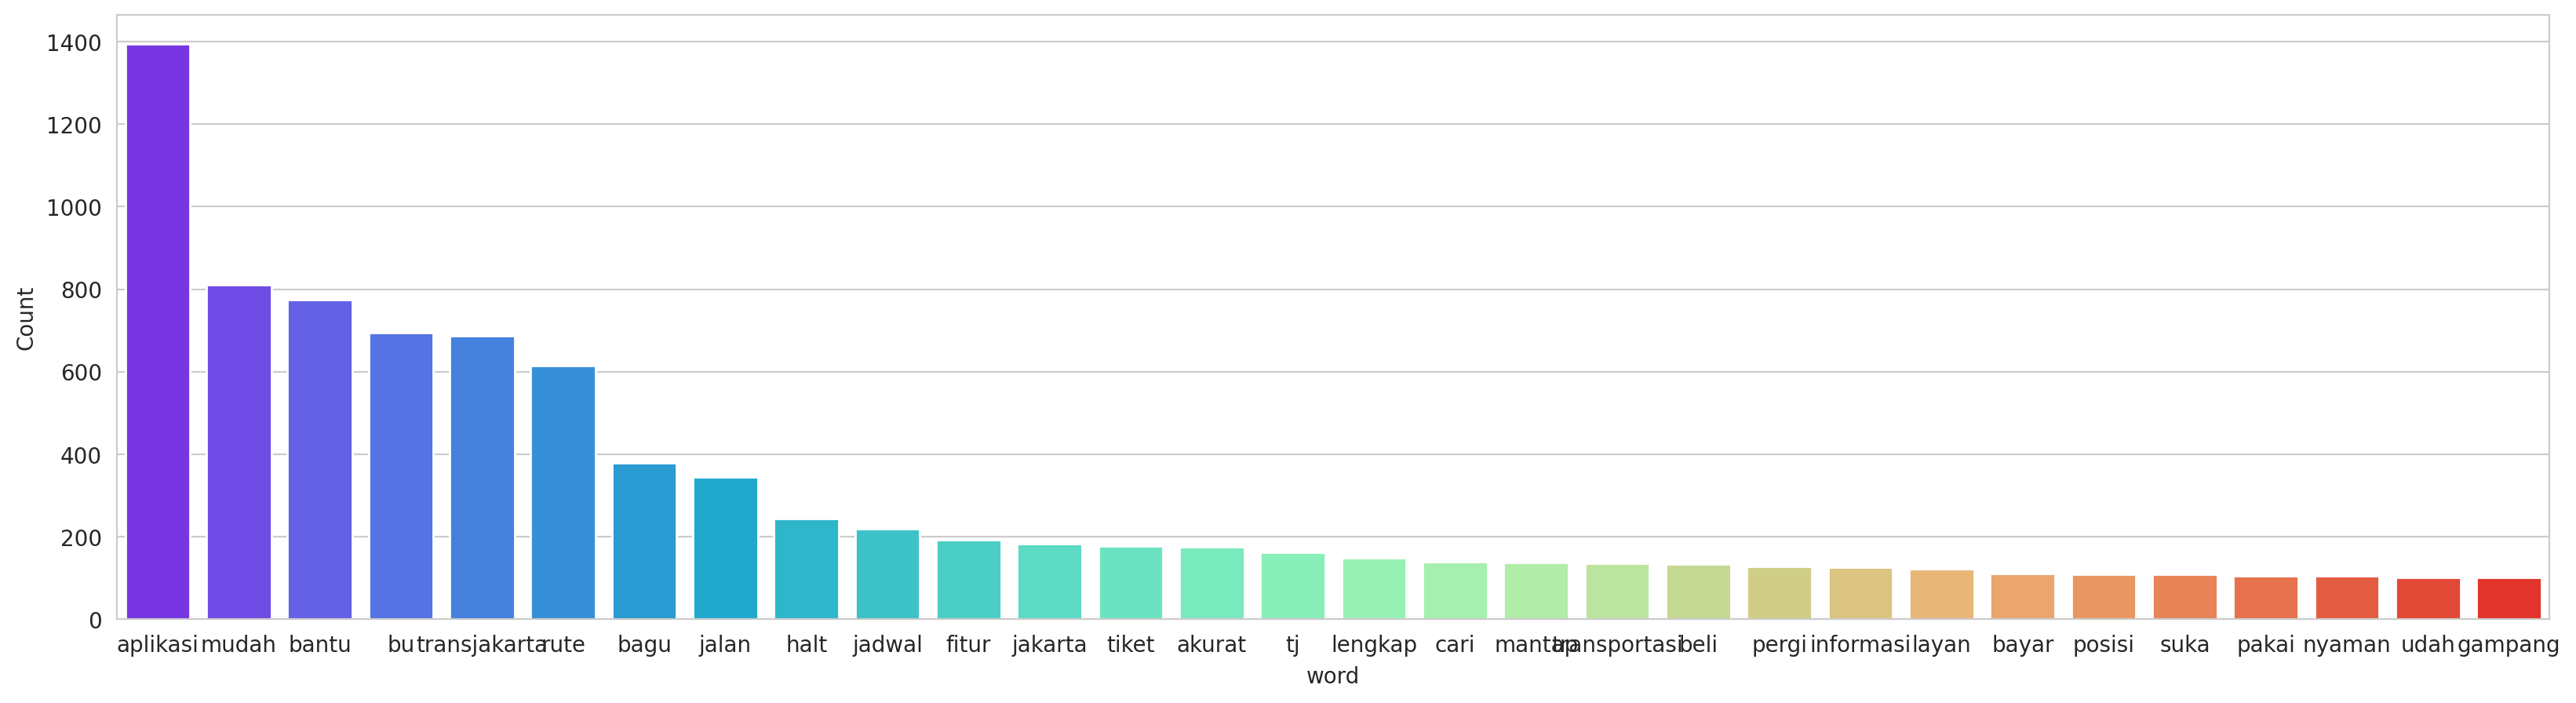

In [ ]:
freq_words(df_tj['cleaned_content_no_common'])

In [ ]:
df_tj.loc[:,["cleaned_content_no_common","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,cleaned_content_no_common,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,udah sempurna tingkat ngehubungin data bu karn...,5,0,2.7.1,2025-09-06 12:30:06,NaN,NaN
1,salah versi tolong,4,0,2.7.1,2025-09-06 11:03:16,NaN,NaN
2,ok,5,0,2.7.1,2025-09-06 04:19:05,NaN,NaN
3,tolong gate scan bikin mudah kadang kadang ngg...,5,0,2.7.1,2025-09-06 01:45:32,NaN,NaN
4,aplikasi pasu kode otp eror,3,0,NaN,2025-09-05 17:19:45,NaN,NaN
...,...,...,...,...,...,...,...
2741,mantap,5,5,1.4,2024-05-16 11:10:02,NaN,NaN
2742,crash pilih profil,5,7,1.8,2024-05-16 04:52:59,NaN,NaN
2743,aplikasi kocag becu bikin aplikasi masuk kerja...,1,7,1.4,2024-05-12 09:42:40,NaN,NaN
2744,aplikasi server eror load cari rute susah posi...,1,23,1.4,2024-05-11 13:43:39,"Halo Teguh Aliansyah,\nTerima kasih untuk masu...",2024-05-23 06:29:46


In [ ]:
df_tj['score'].value_counts()

,count
score,
5,2071
1,421
3,98
2,87
4,69


In [ ]:
df_tj

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,...,tokenized_content,lower_tokenized_content,removed_stopwords_content,lemmatized_content,stemmed_content,cleaned_content,cleaned_content_no_common,sentiment_polarity,sentiment_subjective,sentiment_rating
0,01a956bc-8356-4eec-8bd6-85644d311be0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Udah hampir sempurna ini, mungkin bisa ditingk...",5,0,2.7.1,2025-09-06 12:30:06,NaN,NaN,...,"[Udah, hampir, sempurna, ini, ,, mungkin, bisa...","[udah, hampir, sempurna, ini, ,, mungkin, bisa...","[udah, sempurna, ,, ditingkatkan, ngehubungin,...","[udah, sempurna, , tingkat, ngehubungin, data,...","['udah', 'sempurna', '', 'tingkat', 'ngehubung...",udah sempurna tingkat ngehubungin data bu kar...,udah sempurna tingkat ngehubungin data bu karn...,0.0,0.0,Positive
1,234b7bb0-8ce0-498a-9644-088811e7a521,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kesalahan yang sering terjadi, versi yang lebi...",4,0,2.7.1,2025-09-06 11:03:16,NaN,NaN,...,"[kesalahan, yang, sering, terjadi, ,, versi, y...","[kesalahan, yang, sering, terjadi, ,, versi, y...","[kesalahan, ,, versi, pembaruan, ,, tolong, pe...","[salah, , versi, baru, , tolong, baik]","['salah', '', 'versi', 'baru', '', 'tolong', '...",salah versi baru tolong baik,salah versi tolong,0.0,0.0,Positive
2,06a6c78b-8a8d-4395-9ab7-7ecdd405e7f9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.7.1,2025-09-06 04:19:05,NaN,NaN,...,[ok],[ok],[ok],[ok],['ok'],ok,ok,0.5,0.5,Positive
3,9ec5f40b-63e5-46d3-a9cf-85f8aa8bda29,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong Gate scan nya Di perbaiki dan di bikin ...,5,0,2.7.1,2025-09-06 01:45:32,NaN,NaN,...,"[Tolong, Gate, scan, nya, Di, perbaiki, dan, d...","[tolong, gate, scan, nya, di, perbaiki, dan, d...","[tolong, gate, scan, perbaiki, bikin, mudah, ,...","[tolong, gate, scan, baik, bikin, mudah, , kad...","['tolong', 'gate', 'scan', 'baik', 'bikin', 'm...",tolong gate scan baik bikin mudah kadang kada...,tolong gate scan bikin mudah kadang kadang ngg...,0.0,0.0,Positive
4,3f1c44b5-aef1-4228-aaa2-d647488808c4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi tidak bisa memasukan kode otp selalu ...,3,0,NaN,2025-09-05 17:19:45,NaN,NaN,...,"[aplikasi, tidak, bisa, memasukan, kode, otp, ...","[aplikasi, tidak, bisa, memasukan, kode, otp, ...","[aplikasi, memasukan, kode, otp, peringatan, e...","[aplikasi, pasu, kode, otp, ingat, eror]","['aplikasi', 'pasu', 'kode', 'otp', 'ingat', '...",aplikasi pasu kode otp ingat eror,aplikasi pasu kode otp eror,0.0,0.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,cdd9f5f2-b4cb-44c2-814e-860e0688f3d5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantaps,5,5,1.4,2024-05-16 11:10:02,NaN,NaN,...,[Mantaps],[mantaps],[mantaps],[mantaps],['mantap'],mantap,mantap,0.0,0.0,Positive
2742,66859930-33cc-484a-9c0a-f25534958578,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah enggak crash kalau pilih profil,5,7,1.8,2024-05-16 04:52:59,NaN,NaN,...,"[Sudah, enggak, crash, kalau, pilih, profil]","[sudah, enggak, crash, kalau, pilih, profil]","[crash, pilih, profil]","[crash, pilih, profil]","['crash', 'pilih', 'profil']",crash pilih profil,crash pilih profil,0.0,0.0,Positive
2743,eb386bcd-d074-448e-b636-8f8b4d20ecb1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",1,7,1.4,2024-05-12 09:42:40,NaN,NaN,...,"[Aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, becus, bikin, aplikasi, ,...","[aplikasi, kocag, , becus, bikin, aplikasi, , ...","['aplikasi', 'kocag', '', 'becu', 'bikin', 'ap...",aplikasi kocag becu bikin aplikasi masuk ker...,aplikasi kocag becu bikin aplikasi masuk kerja...,-0.4,

## EDA

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# visualization tools
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
# import pandas_profiling as pp
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df_tj.sample(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,...,tokenized_content,lower_tokenized_content,removed_stopwords_content,lemmatized_content,stemmed_content,cleaned_content,cleaned_content_no_common,sentiment_polarity,sentiment_subjective,sentiment_rating
759,e5dd85ae-c05d-4e3e-8546-1463cdcb30c6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,error terus,1,0,2.4.0,2025-05-14 13:36:11,NaN,NaN,...,"[error, terus]","[error, terus]",[error],[error],['error'],error,error,0.0,0.0,Negative
257,3582055d-7285-44ec-851b-5462c08e664c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Alhamdulillah Terimakasih Apl Tj sangat memban...,5,0,2.5.1,2025-07-21 14:09:43,NaN,NaN,...,"[Alhamdulillah, Terimakasih, Apl, Tj, sangat, ...","[alhamdulillah, terimakasih, apl, tj, sangat, ...","[alhamdulillah, terimakasih, apl, tj, membantu...","[alhamdulillah, terimakasih, apl, tj, bantu, ,...","['alhamdulillah', 'terimakasih', 'apl', 'tj', ...",alhamdulillah terimakasih apl tj bantu siap p...,alhamdulillah terimakasih apl tj bantu pergi p...,0.0,0.0,Positive
391,957501fc-3cc8-4c95-80bb-f11bb1b03e00,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi sangat berguna sekali, karena membant...",5,0,2.5.0,2025-06-29 10:21:27,NaN,NaN,...,"[Aplikasi, sangat, berguna, sekali, ,, karena,...","[aplikasi, sangat, berguna, sekali, ,, karena,...","[aplikasi, berguna, ,, membantu, memberitahuka...","[aplikasi, guna, , bantu, memberitahukan, rute...","['aplikasi', 'guna', '', 'bantu', 'memberitahu...",aplikasi guna bantu memberitahukan rute jadwa...,aplikasi bantu memberitahukan rute jadwal bera...,0.0,0.0,Positive
1510,7c8948a1-b3e5-4a3b-b78c-87ab16eea805,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ga bakal nyesel si pake aplikasi ini karena me...,5,0,2.1.5,2024-12-02 07:25:02,NaN,NaN,...,"[ga, bakal, nyesel, si, pake, aplikasi, ini, k...","[ga, bakal, nyesel, si, pake, aplikasi, ini, k...","[nyesel, si, pake, aplikasi, berguna, woii, ap...","[nyesel, si, pake, aplikasi, guna, woii, aplik...","['nyesel', 'si', 'pake', 'aplikasi', 'guna', '...",nyesel si pake aplikasi guna woii aplikasi tam...,nyesel si pake aplikasi woii aplikasi tampil m...,0.0,0.0,Positive
1520,40d183c7-390d-43ae-93a0-33b7b9c05f3f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplksi sngt bagus, tidak pusing melihat rute² ...",5,0,2.1.5,2024-11-30 03:06:57,NaN,NaN,...,"[Aplksi, sngt, bagus, ,, tidak, pusing, meliha...","[aplksi, sngt, bagus, ,, tidak, pusing, meliha...","[aplksi, sngt, bagus, ,, pusing, rute², jalan,...","[aplksi, sngt, bagus, , pusing, rute, jalan, ,...","['aplksi', 'sngt', 'bagu', '', 'puse', 'rute',...",aplksi sngt bagu puse rute jalan mudah trans...,aplksi sngt bagu puse rute jalan mudah transpo...,0.0,0.0,Positive


In [ ]:
df_tj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2746 entries, 0 to 2745
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   reviewId                   2746 non-null   object 
 1   userName                   2746 non-null   object 
 2   userImage                  2746 non-null   object 
 3   content                    2746 non-null   object 
 4   score                      2746 non-null   int64  
 5   thumbsUpCount              2746 non-null   int64  
 6   reviewCreatedVersion       2324 non-null   object 
 7   at                         2746 non-null   object 
 8   replyContent               4 non-null      object 
 9   repliedAt                  4 non-null      object 
 10  appVersion                 2324 non-null   object 
 11  tokenized_content          2746 non-null   object 
 12  lower_tokenized_content    2746 non-null   object 
 13  removed_stopwords_content  2746 non-null   objec

In [ ]:
df_tj.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,422
at,0
replyContent,2742
repliedAt,2742


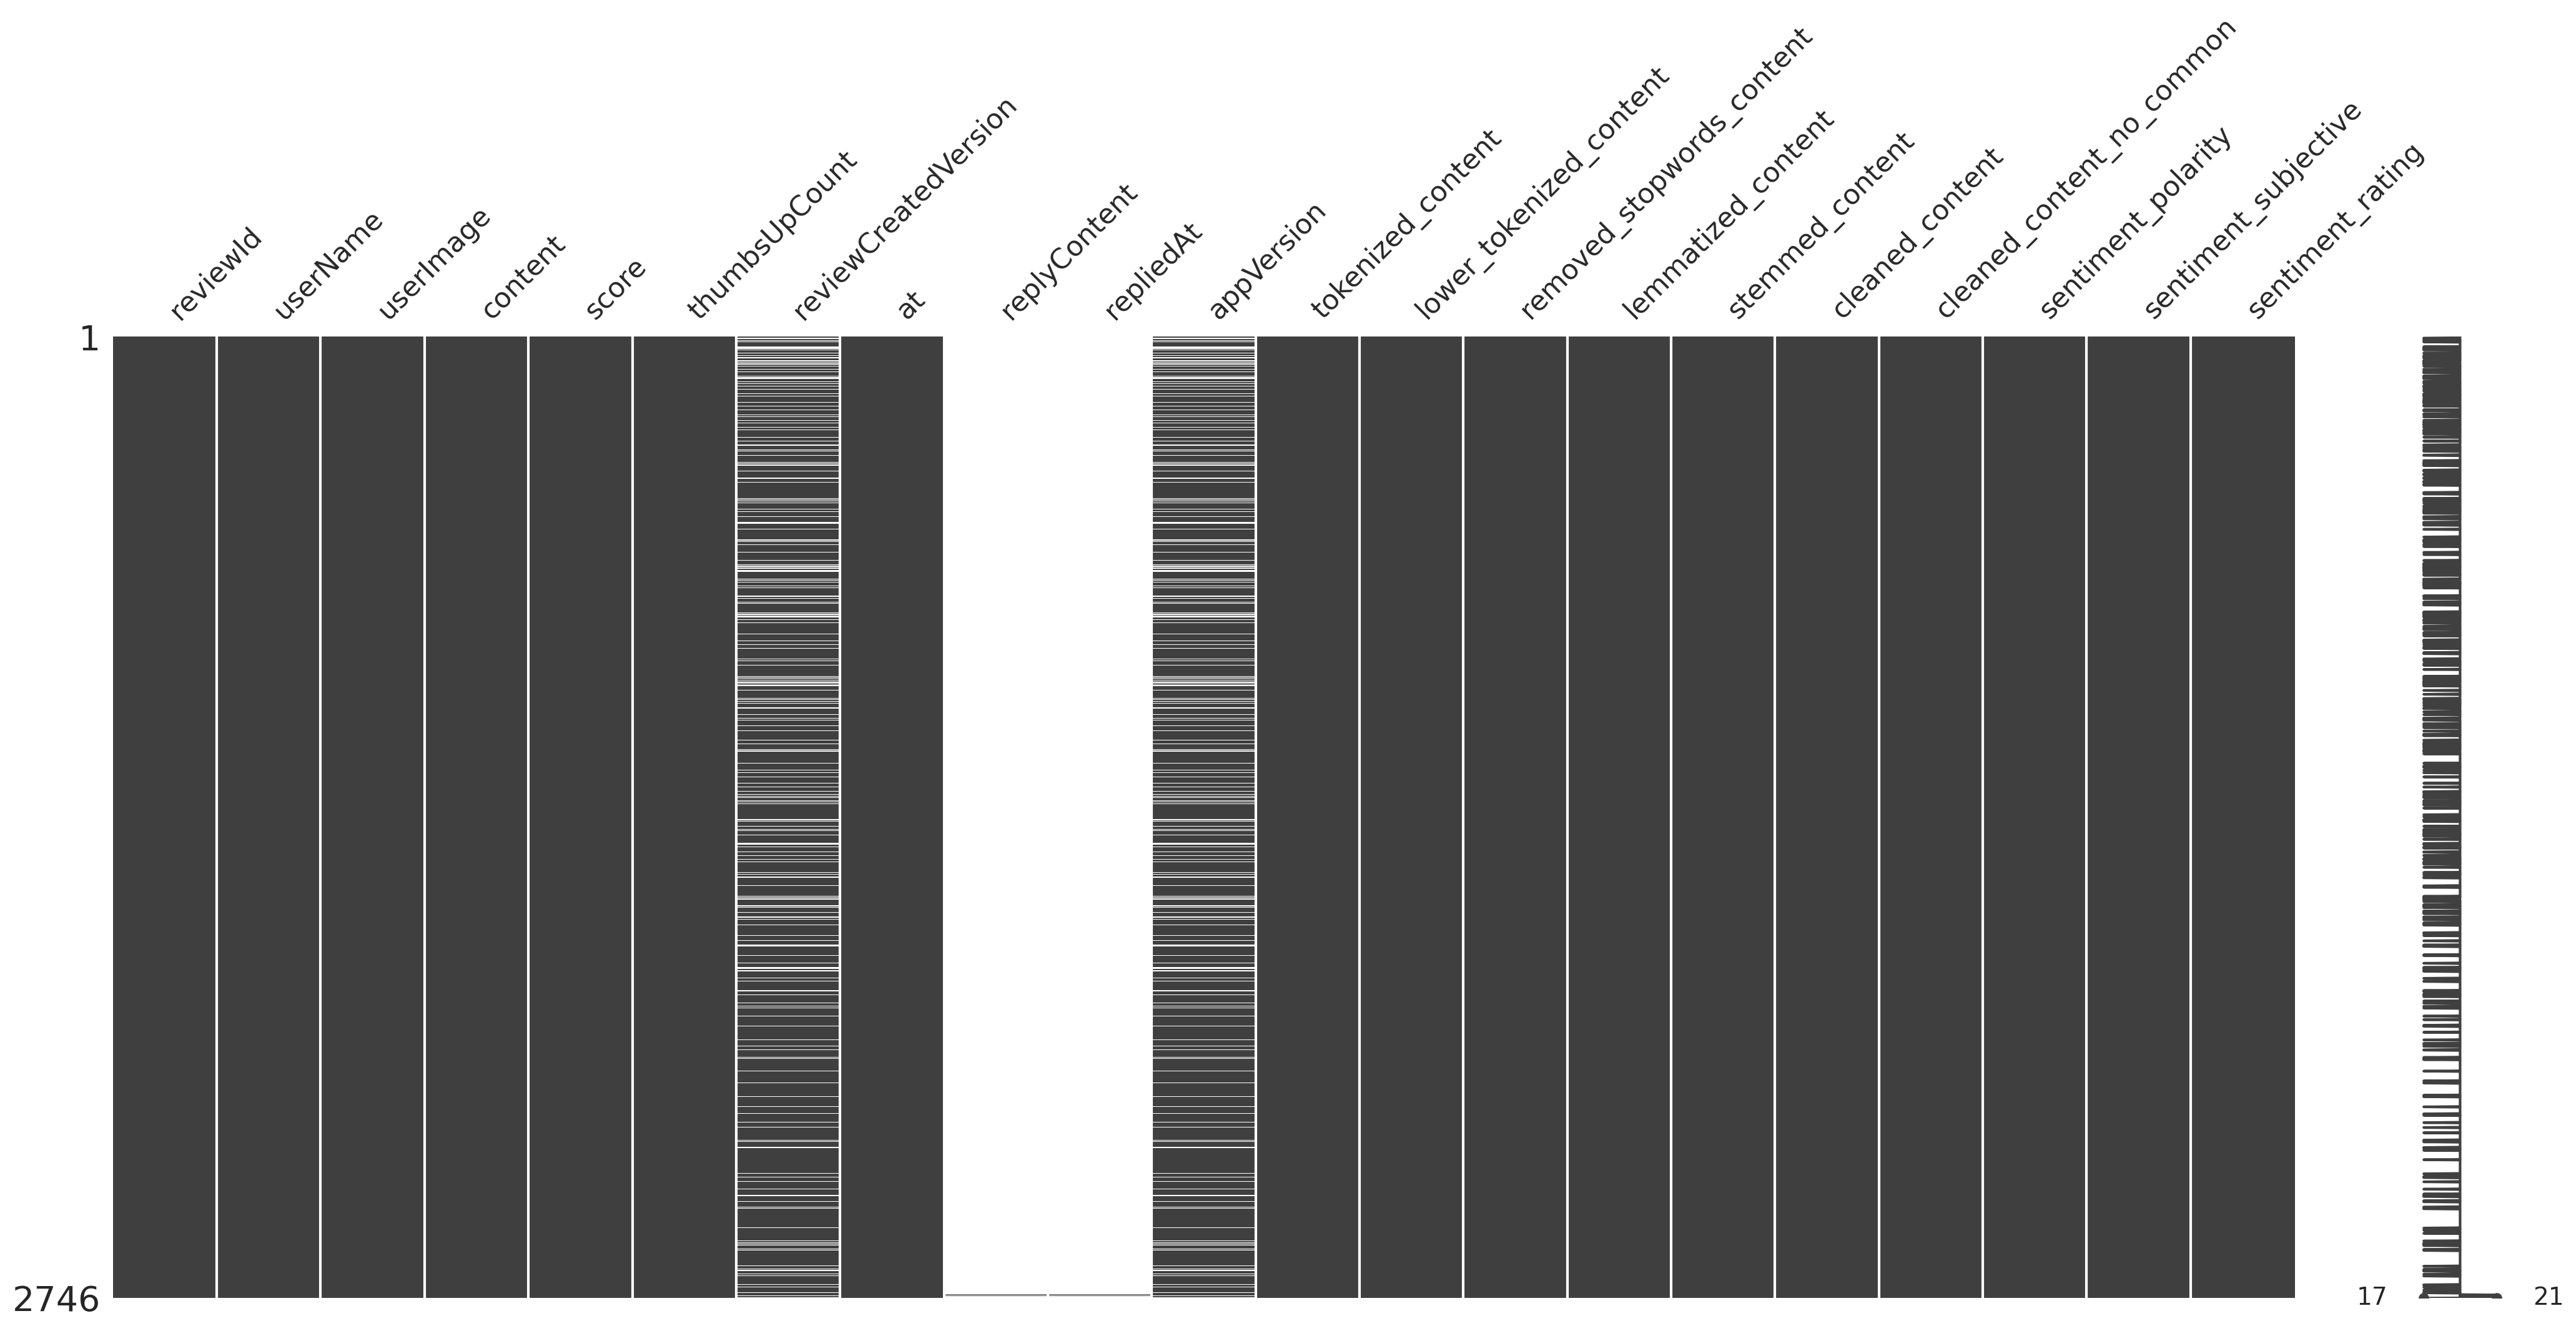

In [ ]:
import missingno as msno
msno.matrix(df_tj)
plt.show()

In [ ]:
# Assuming 'df_tj' is your DataFrame
df_tj['at'] = pd.to_datetime(df_tj['at'])
df_tj['year'] = df_tj['at'].dt.year

# Select only the desired columns
df_selected = df_tj[['content', 'cleaned_content_no_common', 'score', 'sentiment_rating', 'at', 'year']]

# Display the selected columns
df_selected

,content,cleaned_content_no_common,score,sentiment_rating,at,year
0,"Udah hampir sempurna ini, mungkin bisa ditingk...",udah sempurna tingkat ngehubungin data bu karn...,5,Positive,2025-09-06 12:30:06,2025
1,"kesalahan yang sering terjadi, versi yang lebi...",salah versi tolong,4,Positive,2025-09-06 11:03:16,2025
2,ok,ok,5,Positive,2025-09-06 04:19:05,2025
3,Tolong Gate scan nya Di perbaiki dan di bikin ...,tolong gate scan bikin mudah kadang kadang ngg...,5,Positive,2025-09-06 01:45:32,2025
4,aplikasi tidak bisa memasukan kode otp selalu ...,aplikasi pasu kode otp eror,3,Neutral,2025-09-05 17:19:45,2025
...,...,...,...,...,...,...
2741,Mantaps,mantap,5,Positive,2024-05-16 11:10:02,2024
2742,Sudah enggak crash kalau pilih profil,crash pilih profil,5,Positive,2024-05-16 04:52:59,2024
2743,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",aplikasi kocag becu bikin aplikasi masuk kerja...,1,Negative,2024-05-12 09:42:40,2024
2744,"Aplikasi gak jelas, server eror, loading lama,...",aplikasi server eror load cari rute susah posi...,1,Negative,2024-05-11 13:43:39,2024


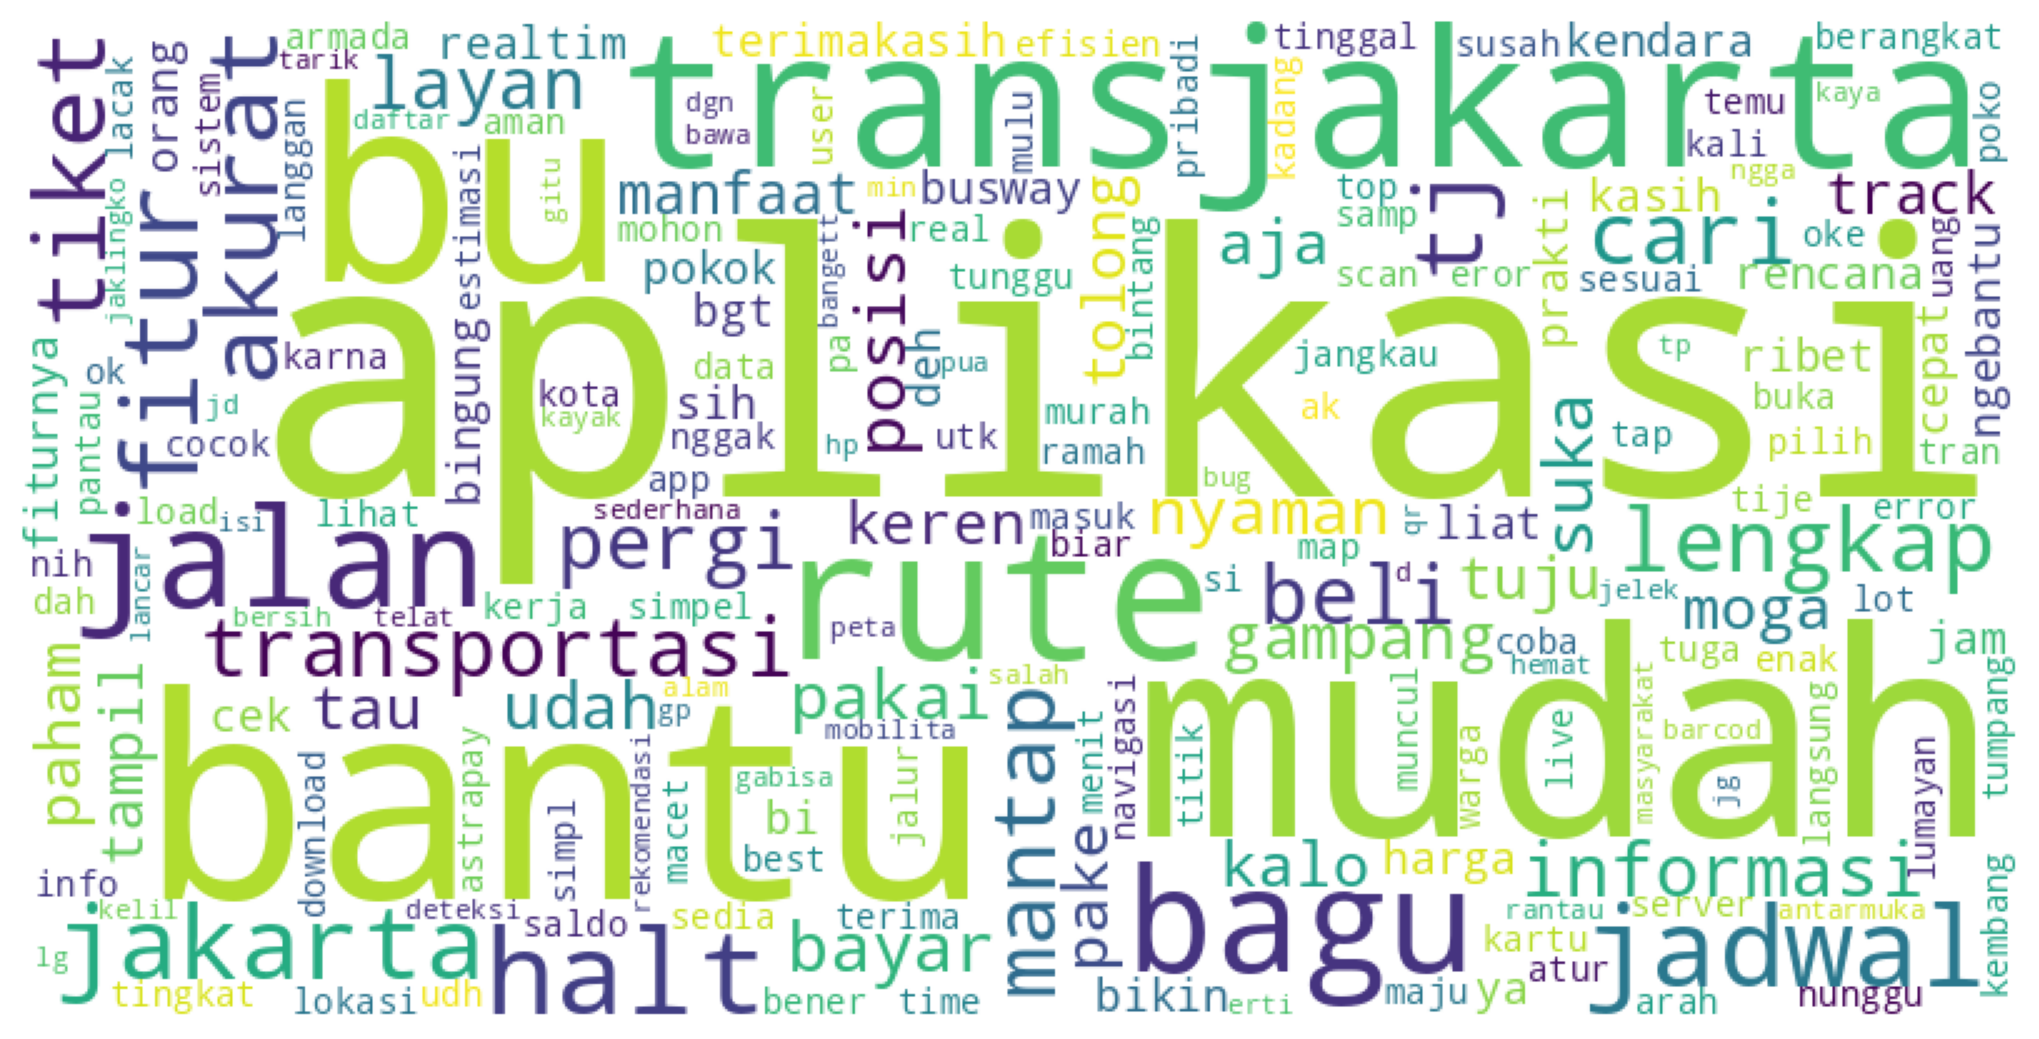

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text data into a single string
all_text = ' '.join(df_tj['cleaned_content_no_common'].dropna().astype(str))

# Create a WordCloud object with unique word functionality
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      collocations=False).generate(all_text)

# Display the generated image:
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

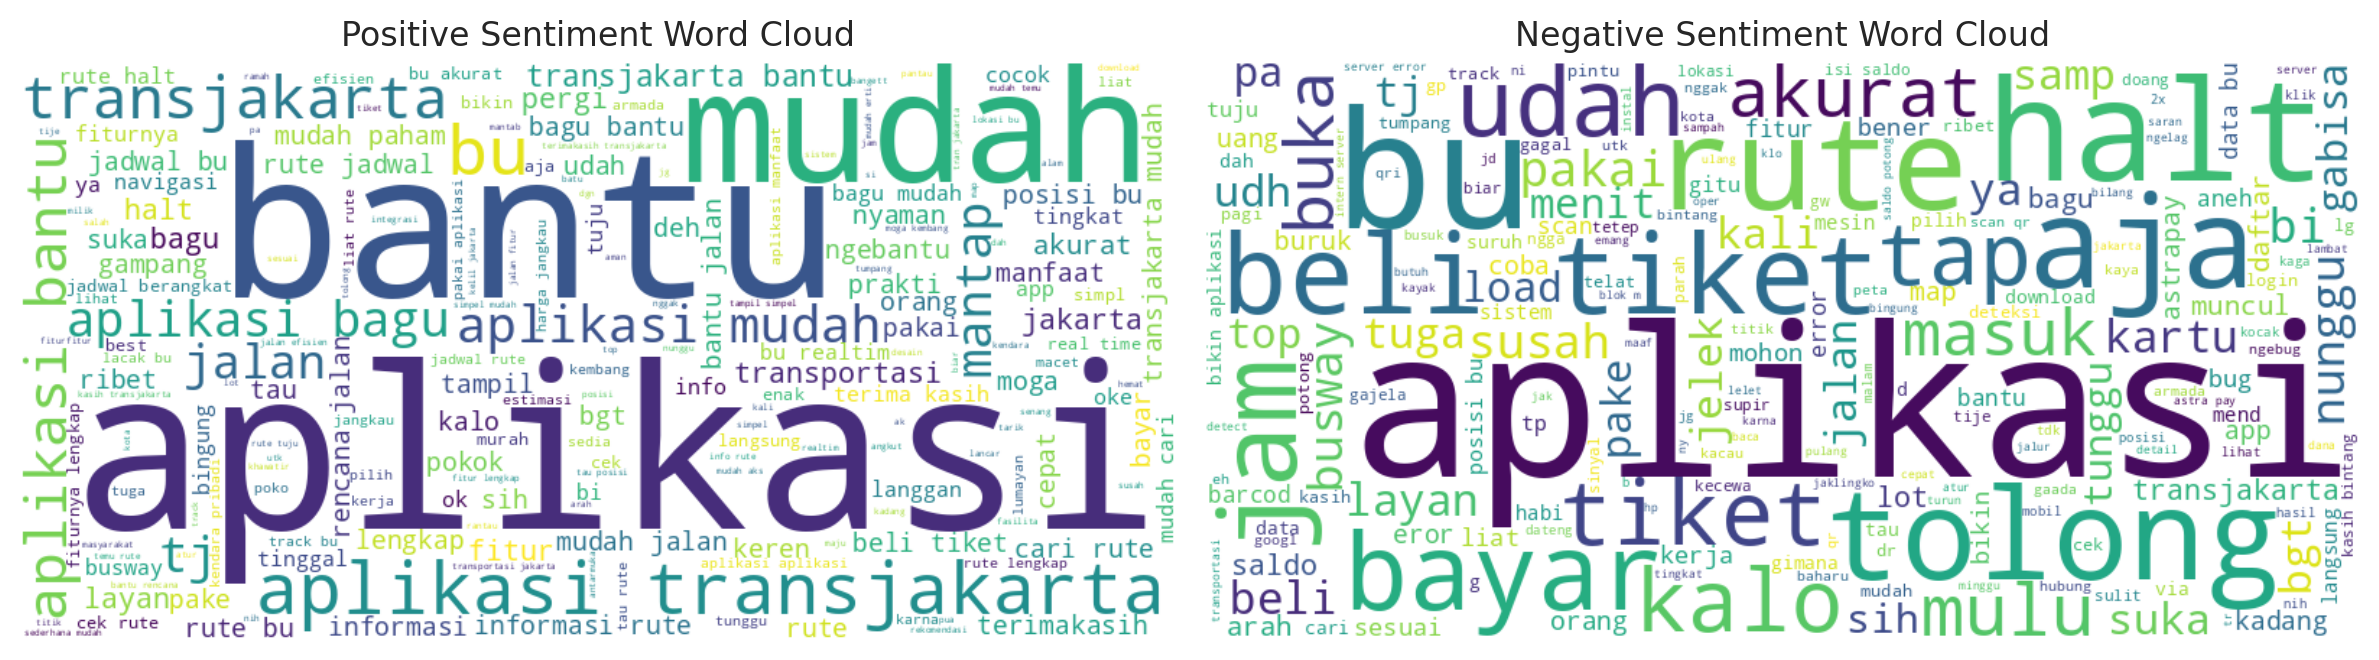

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate reviews into positive and negative sentiment groups
positive_reviews = df_tj[df_tj['sentiment_rating'] == 'Positive']['cleaned_content_no_common'].astype(str)
negative_reviews = df_tj[df_tj['sentiment_rating'] == 'Negative']['cleaned_content_no_common'].astype(str)

# Create word clouds for positive and negative sentiments
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(positive_reviews))
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(negative_reviews))

# Display the word clouds
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Sentiment Word Cloud')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Sentiment Word Cloud')
plt.axis("off")

plt.tight_layout()
plt.show()

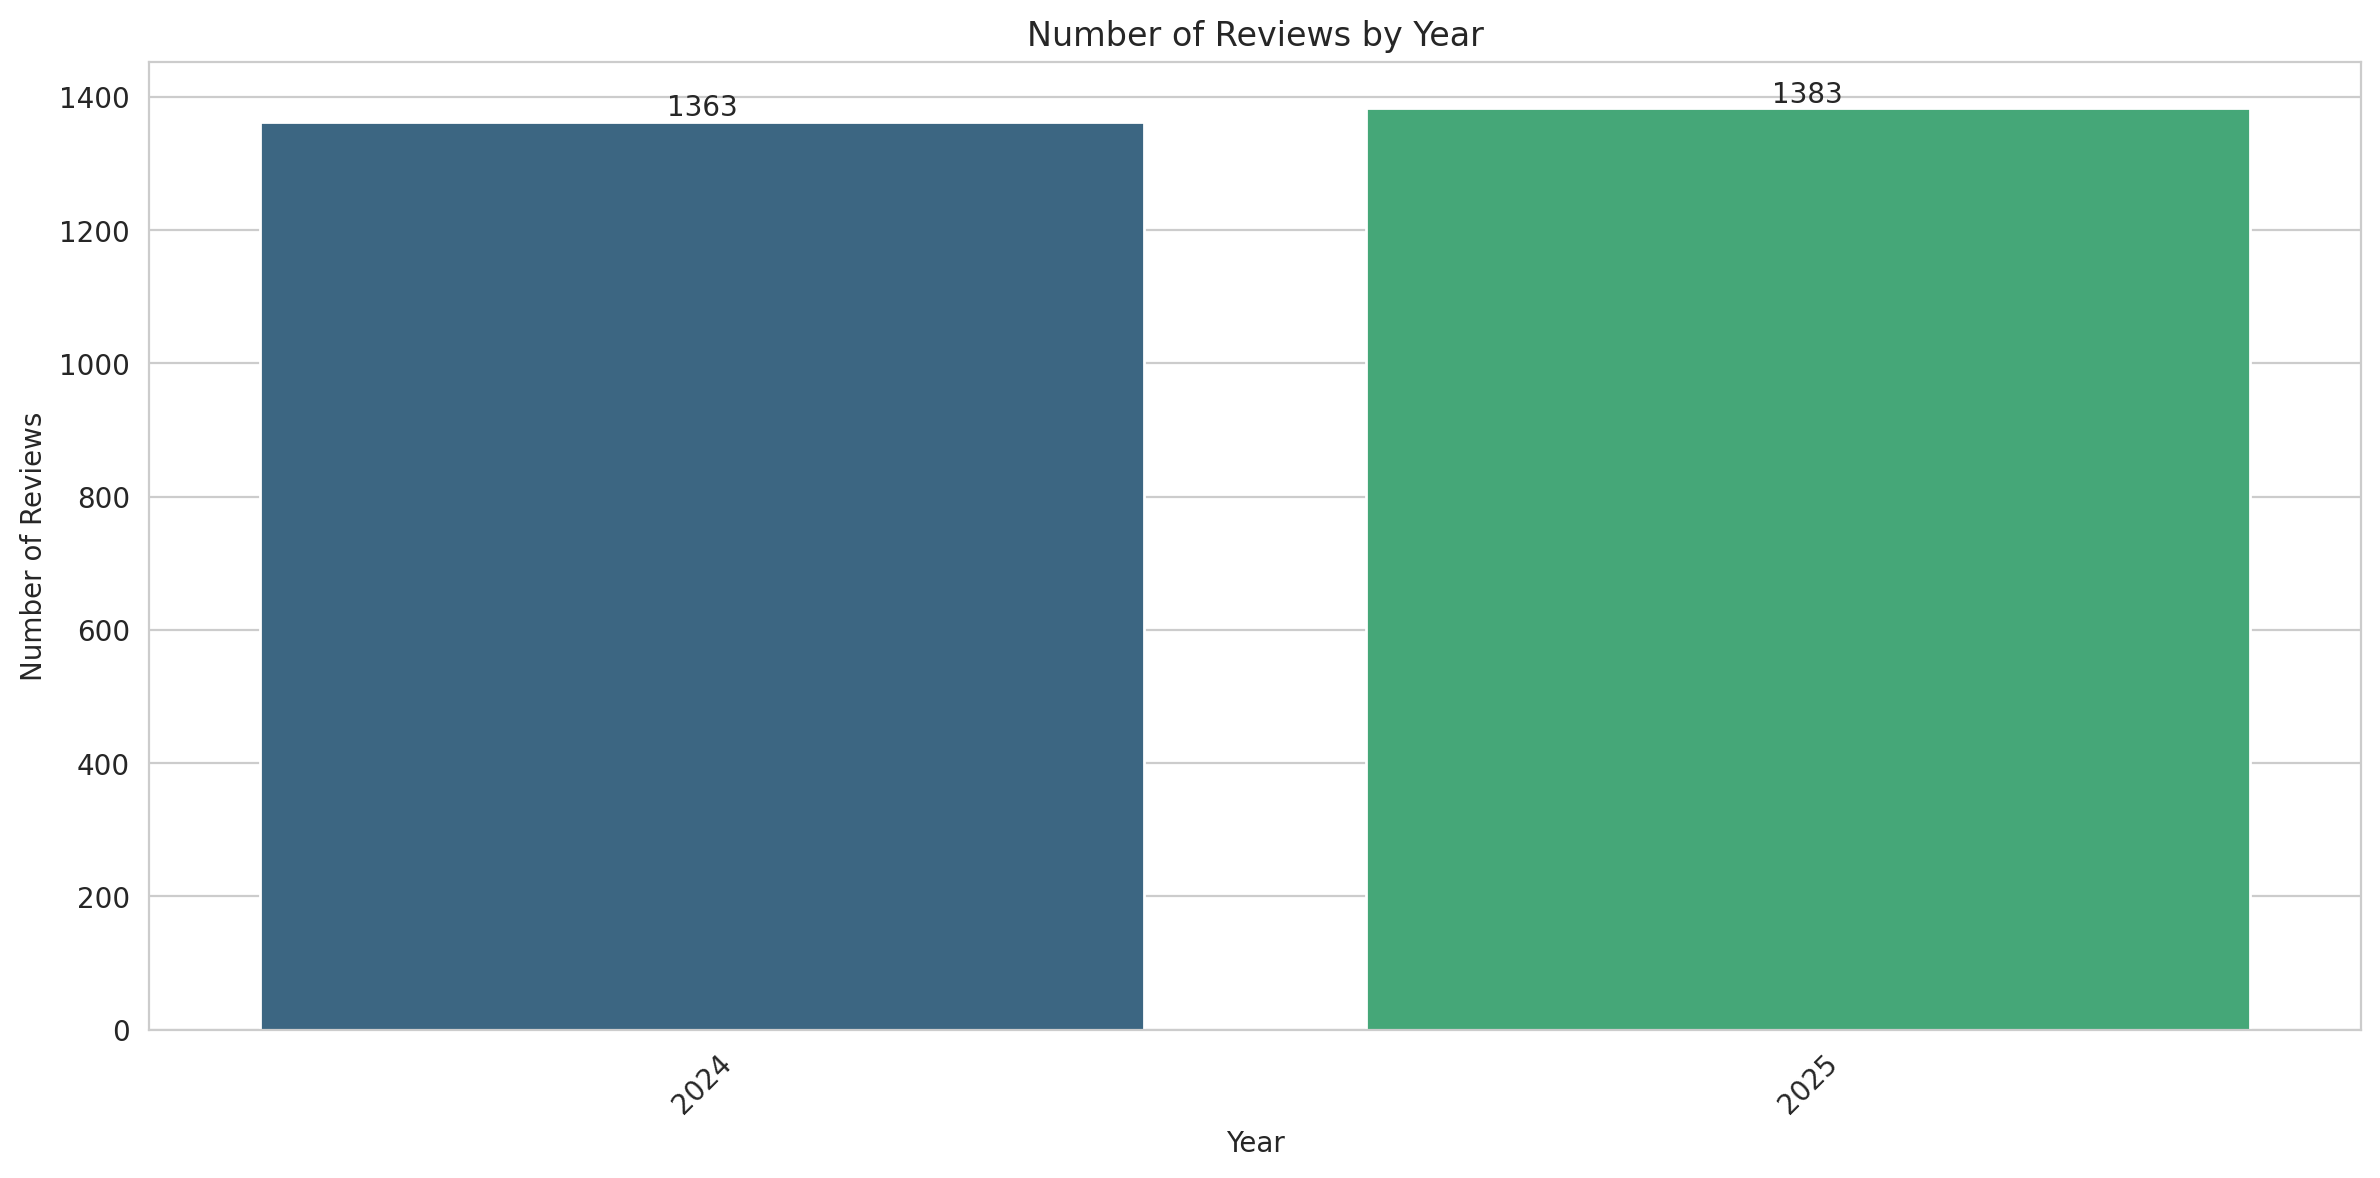

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and count the number of reviews
reviews_by_year = df_tj.groupby('year')['content'].count()

# Create the barplot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=reviews_by_year.index, y=reviews_by_year.values, palette="viridis")

# Customize the plot
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews by Year")

# Rotate x-axis labels if needed
plt.xticks(rotation=45)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

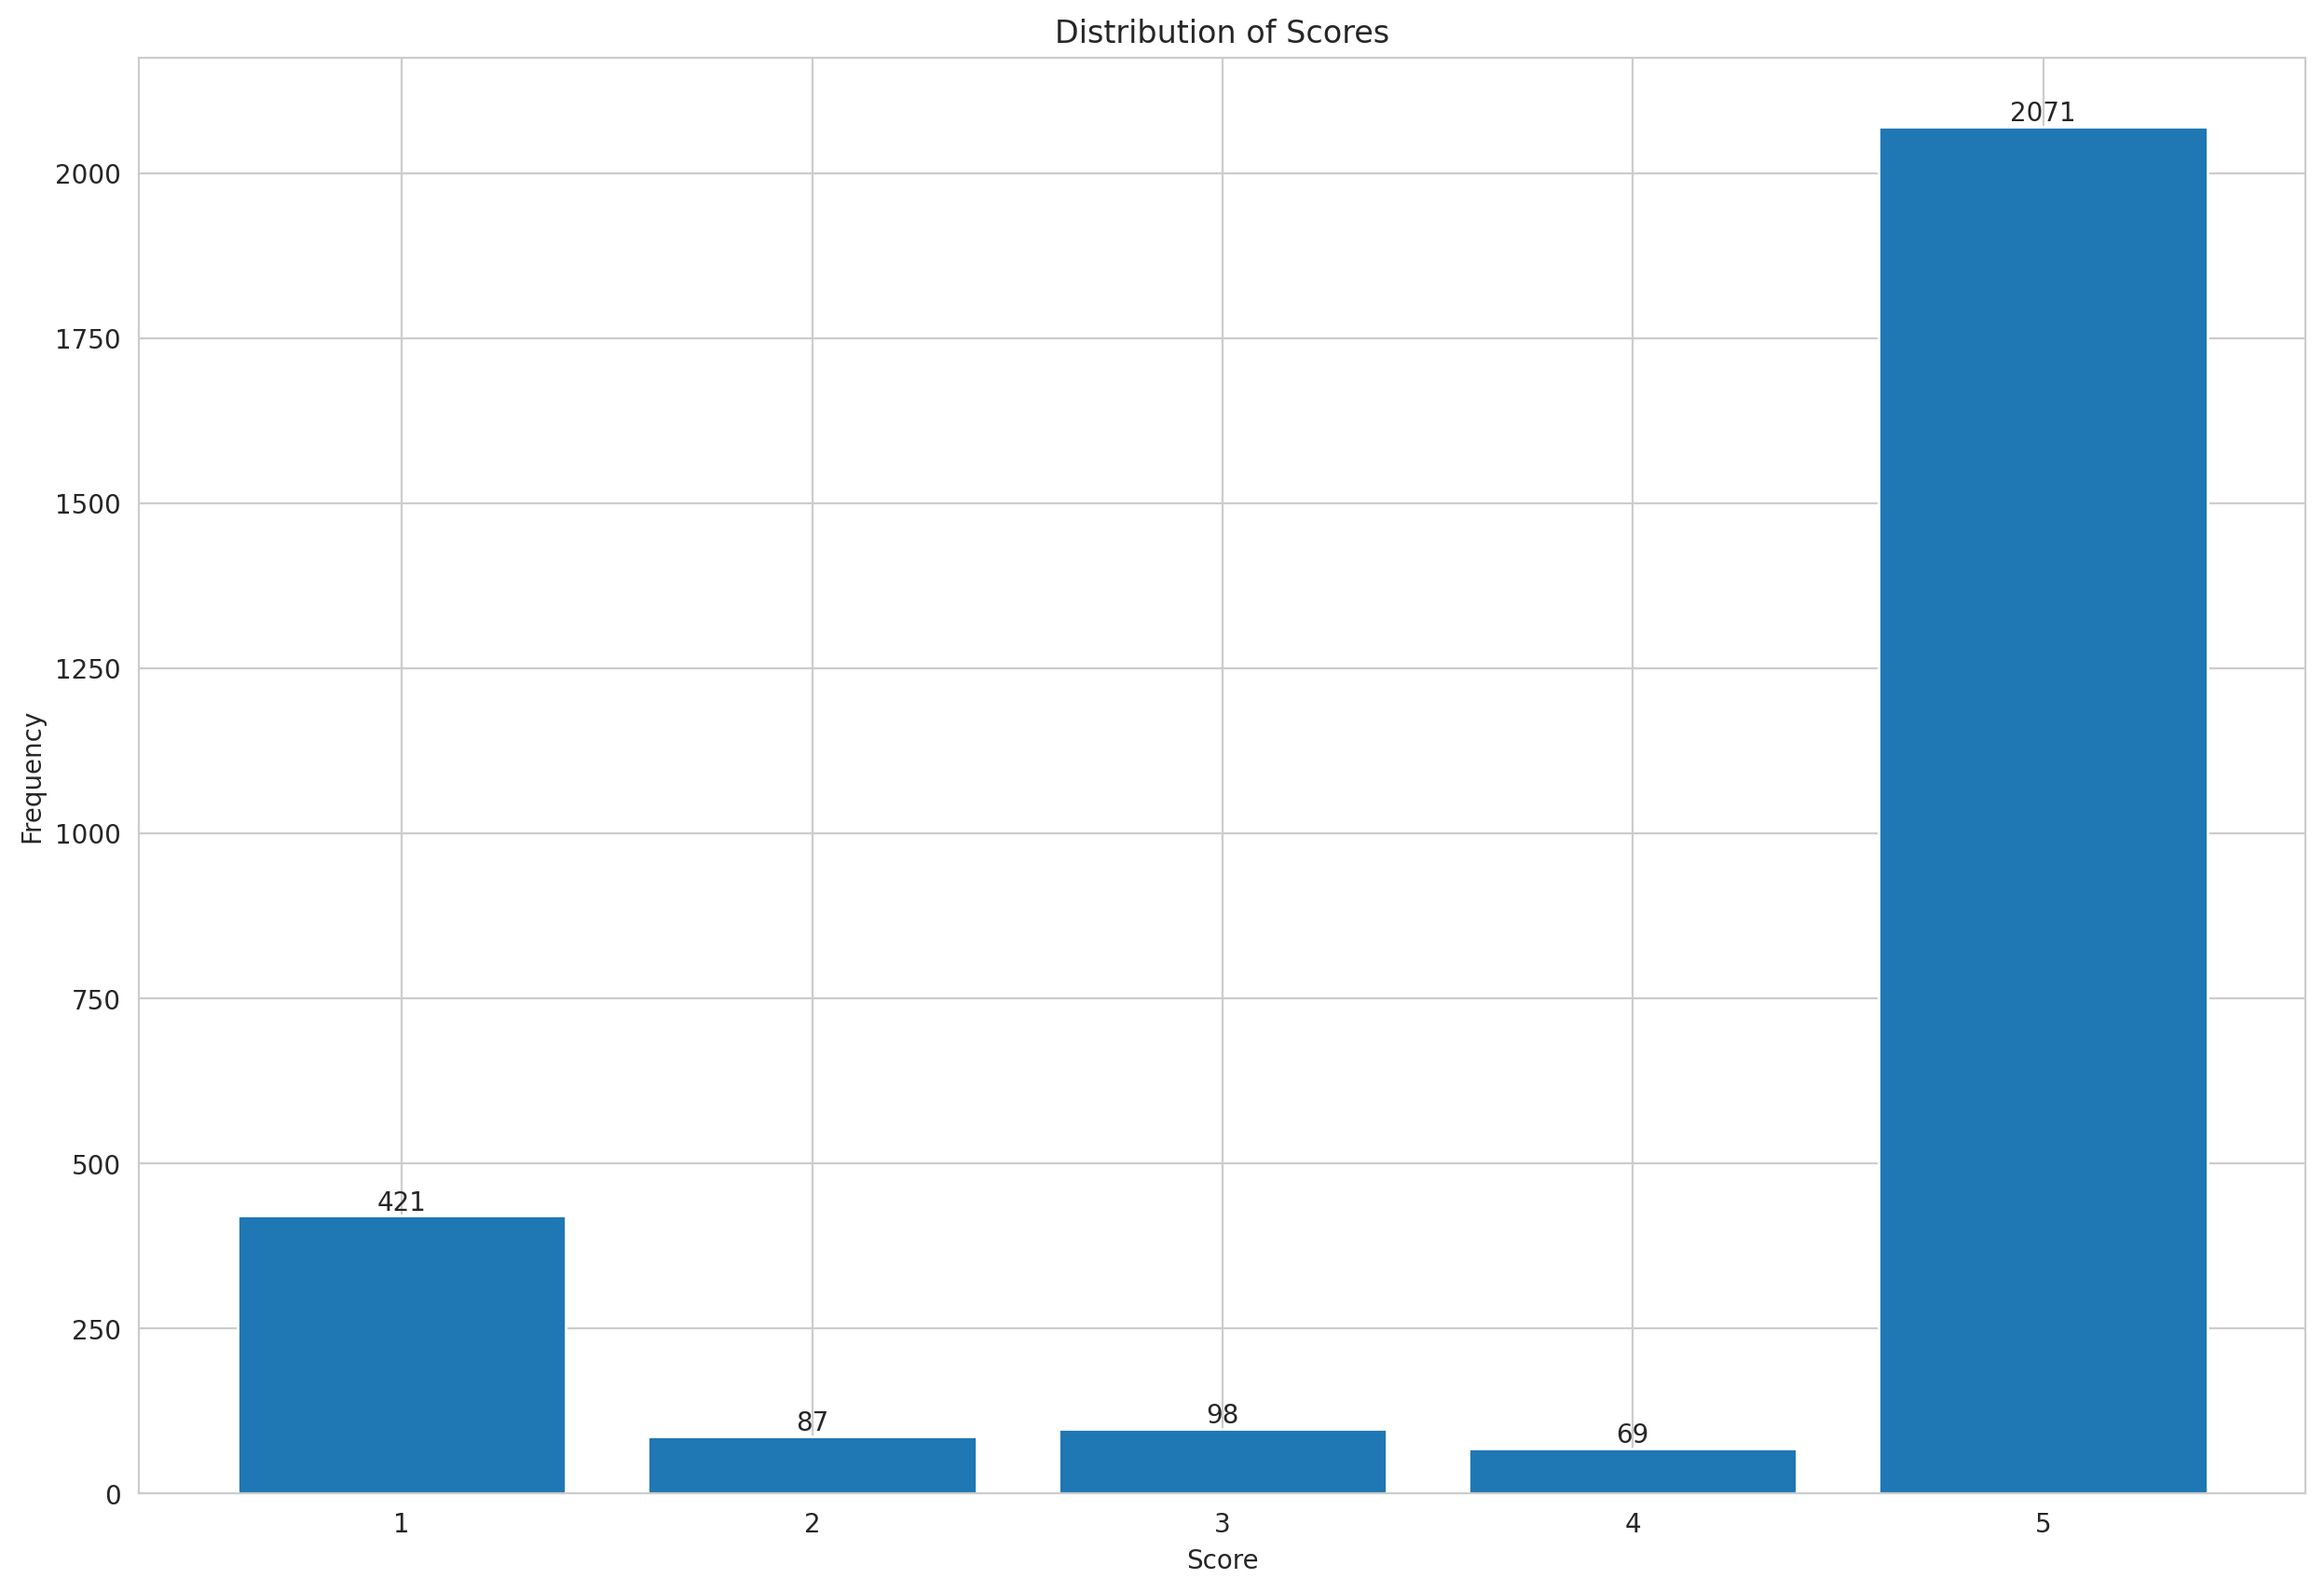

In [ ]:
# Create the histogram of the 'score' column.
fig, ax = plt.subplots()
counts, bins, patches = ax.hist(df_tj['score'], bins=np.arange(1, 7) - 0.5, rwidth=0.8)

# Set the x-axis ticks to be the integers 1, 2, 3, 4, and 5.
ax.set_xticks([1, 2, 3, 4, 5])

# Add labels and a title for clarity.
ax.set_xlabel('Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Scores')

# Add detail labels for each value (bar).
for count, patch in zip(counts, patches):
    # Get the x and y coordinates for the text
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    # Add the text label
    ax.text(x, y, str(int(count)), ha='center', va='bottom')

In [ ]:
#save df to local
df_tj.to_csv('df_tj_clean.csv', index=False)


# To download the file to your local machine:
from google.colab import files
files.download('df_tj_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_tj

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,...,lower_tokenized_content,removed_stopwords_content,lemmatized_content,stemmed_content,cleaned_content,cleaned_content_no_common,sentiment_polarity,sentiment_subjective,sentiment_rating,year
0,01a956bc-8356-4eec-8bd6-85644d311be0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Udah hampir sempurna ini, mungkin bisa ditingk...",5,0,2.7.1,2025-09-06 12:30:06,NaN,NaN,...,"[udah, hampir, sempurna, ini, ,, mungkin, bisa...","[udah, sempurna, ,, ditingkatkan, ngehubungin,...","[udah, sempurna, , tingkat, ngehubungin, data,...","['udah', 'sempurna', '', 'tingkat', 'ngehubung...",udah sempurna tingkat ngehubungin data bu kar...,udah sempurna tingkat ngehubungin data bu karn...,0.0,0.0,Positive,2025
1,234b7bb0-8ce0-498a-9644-088811e7a521,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kesalahan yang sering terjadi, versi yang lebi...",4,0,2.7.1,2025-09-06 11:03:16,NaN,NaN,...,"[kesalahan, yang, sering, terjadi, ,, versi, y...","[kesalahan, ,, versi, pembaruan, ,, tolong, pe...","[salah, , versi, baru, , tolong, baik]","['salah', '', 'versi', 'baru', '', 'tolong', '...",salah versi baru tolong baik,salah versi tolong,0.0,0.0,Positive,2025
2,06a6c78b-8a8d-4395-9ab7-7ecdd405e7f9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,2.7.1,2025-09-06 04:19:05,NaN,NaN,...,[ok],[ok],[ok],['ok'],ok,ok,0.5,0.5,Positive,2025
3,9ec5f40b-63e5-46d3-a9cf-85f8aa8bda29,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tolong Gate scan nya Di perbaiki dan di bikin ...,5,0,2.7.1,2025-09-06 01:45:32,NaN,NaN,...,"[tolong, gate, scan, nya, di, perbaiki, dan, d...","[tolong, gate, scan, perbaiki, bikin, mudah, ,...","[tolong, gate, scan, baik, bikin, mudah, , kad...","['tolong', 'gate', 'scan', 'baik', 'bikin', 'm...",tolong gate scan baik bikin mudah kadang kada...,tolong gate scan bikin mudah kadang kadang ngg...,0.0,0.0,Positive,2025
4,3f1c44b5-aef1-4228-aaa2-d647488808c4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi tidak bisa memasukan kode otp selalu ...,3,0,NaN,2025-09-05 17:19:45,NaN,NaN,...,"[aplikasi, tidak, bisa, memasukan, kode, otp, ...","[aplikasi, memasukan, kode, otp, peringatan, e...","[aplikasi, pasu, kode, otp, ingat, eror]","['aplikasi', 'pasu', 'kode', 'otp', 'ingat', '...",aplikasi pasu kode otp ingat eror,aplikasi pasu kode otp eror,0.0,0.0,Neutral,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,cdd9f5f2-b4cb-44c2-814e-860e0688f3d5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantaps,5,5,1.4,2024-05-16 11:10:02,NaN,NaN,...,[mantaps],[mantaps],[mantaps],['mantap'],mantap,mantap,0.0,0.0,Positive,2024
2742,66859930-33cc-484a-9c0a-f25534958578,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sudah enggak crash kalau pilih profil,5,7,1.8,2024-05-16 04:52:59,NaN,NaN,...,"[sudah, enggak, crash, kalau, pilih, profil]","[crash, pilih, profil]","[crash, pilih, profil]","['crash', 'pilih', 'profil']",crash pilih profil,crash pilih profil,0.0,0.0,Positive,2024
2743,eb386bcd-d074-448e-b636-8f8b4d20ecb1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",1,7,1.4,2024-05-12 09:42:40,NaN,NaN,...,"[aplikasi, kocag, ,, gk, becus, bikin, aplikas...","[aplikasi, kocag, ,, becus, bikin, aplikasi, ,...","[aplikasi, kocag, , becus, bikin, aplikasi, , ...","['aplikasi', 'kocag', '', 'becu', 'bikin', 'ap...",aplikasi kocag becu bikin aplikasi masuk ker...,aplikasi kocag becu bikin aplikasi masuk kerja...,-0.4,0.4,Negative,2024
2744,43b40878-dcff-44b8-bed5-2dfb89bc0880,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi gak jelas, server eror, loading lama,...",1,23,1.4,2024-05-11 13:43:39,"Halo Teguh Aliansyah,\nTerima kasih untuk masu...",2024-05-23 06:29:46,...,"[aplikasi, gak, 